# Multi-Experiment Analysis

### Hyperparameter space
|Hyperparameter|Type|Range (Original)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

### 100K Dataset

| Run | Best | Trials | Epochs | Eval<br>every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>reporting | Objective | Prunning | MOO | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|8 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |

### 1M Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective |  Objective | Prunning | MOO  | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|2 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |
 

In [4]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances, plot_pareto_front
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

color_map = {'1c1d': '#5CAF50',
             '1c2d': 'skyblue',
             '1c3d': 'salmon',
             'full': 'forestgreen'}

pd.set_option('display.max_columns',None)

#exp_name = 'e_100K'
#exp_name = 'e_gowalla'
exp_name = 'all'
#version=f'historic_results/{exp_name}/pass_0/'
#version=f'historic_results/sandbox/'
version=f'historic_results/all/'

experiments = [f'historic_results/e_100K/pass_8/e_100K.parquet',
               f'historic_results/e_1M/pass_3/e_1M.parquet',
               f'historic_results/e_gowalla/pass_0/e_gowalla.parquet',
               f'historic_results/e_yelp/pass_0/e_yelp.parquet',
               f'historic_results/e_amazon/pass_0/e_amazon.parquet']

users_map = {'100K': 610, '1M': 6040, 'gowalla': 29858, 'yelp': 31668, 'amazon':52643}
items_map = {'100K': 9724, '1M': 3706, 'gowalla': 40981, 'yelp':  38048, 'amazon':91599}
interactions_map = {'100K': 100836, '1M': 1000209, 'gowalla': 1027370, 'yelp':  1561406, 'amazon':2984108}
users_map_train = {'100K': 610, '1M': 6040, 'gowalla': 29858, 'yelp': 31668, 'amazon':52643}
items_map_train = {'100K': 9003, '1M': 3682, 'gowalla': 40981, 'yelp':  38048, 'amazon':91599}
interactions_map_train = {'100K': 81200, '1M': 805443, 'gowalla': 845292, 'yelp':  1274132, 'amazon':2429444}

total_numbers = pd.DataFrame({'total_users':users_map, 'total_items':items_map, 'total_interactions':interactions_map,
                              'train_users':users_map_train, 'train_items':items_map_train, 'train_interactions':interactions_map_train})
total_numbers['total_nodes'] = total_numbers['total_users'] + total_numbers['total_items']
total_numbers['train_nodes'] = total_numbers['train_users'] + total_numbers['train_items']
total_numbers.reset_index()

,index,total_users,total_items,total_interactions,train_users,train_items,train_interactions,total_nodes,train_nodes
0,100K,610,9724,100836,610,9003,81200,10334,9613
1,1M,6040,3706,1000209,6040,3682,805443,9746,9722
2,gowalla,29858,40981,1027370,29858,40981,845292,70839,70839
3,yelp,31668,38048,1561406,31668,38048,1274132,69716,69716
4,amazon,52643,91599,2984108,52643,91599,2429444,144242,144242


In [5]:
from helper_functions import *
user_mapping, movie_mapping, edge_index = load_data_generic('e_amazon')
train_indices, val_indices, test_indices, train_edge_index, val_edge_index, test_edge_index = split_data_stratified(edge_index)
len(train_edge_index[0].unique()), len(train_edge_index[1].unique()), len(train_edge_index[0])

(52643, 91599, 2429444)

In [6]:
dfs = []
evals_at_epochs = []

for experiment in experiments:
    df = pd.read_parquet(experiment)
    df = df.sort_values('experiment', ascending=True)
    dfs.append(df)
    eval_at_epochs = df['epochs_per_eval'].unique()[0]
    evals_at_epochs.append(eval_at_epochs)

df = pd.concat(dfs, axis=0).reset_index(drop=True)
df.head()


,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
0,e_100K_1c1dcs,0.346382,0.050714,0.040738,0.056046,0.349949,0.056923,0.046885,0.063436,2111.864472,4.238313,0.090695,602,8976,65267,9818,9818,50,True,ndcg,1,64,0.000513,0.002743,2427,RMSprop,"[0.6955503225326538, 0.6622296571731567, 0.589...","[0.6821370720863342, 0.6567513942718506, 0.597...","[0.001981715610979414, 0.011228764984880266, 0...","[0.001557377049180328, 0.00778688524590164, 0....","[0.0019550073365925762, 0.01051990387693092, 0...",0.057651,0.041475,0.060228,900,True,303.0,232.0,20.437767
1,e_100K_1c1dcs_rand1,0.283489,0.106351,0.050820,0.089819,0.279020,0.116738,0.057131,0.097914,1960.147073,5.591445,0.095832,610,8336,65267,9818,9818,50,True,ndcg,1,128,0.000505,0.000129,1510,RMSprop,"[0.6888307332992554, 0.65843665599823, 0.59260...","[0.661415696144104, 0.6409842371940613, 0.5899...","[0.0012763763614944668, 0.005237010968202474, ...","[0.0012295081967213116, 0.0036885245901639345,...","[0.0015655492274079265, 0.005493919417540514, ...",0.108118,0.052459,0.092259,1300,True,NaN,NaN,NaN
2,e_100K_1c1dcs_rand2,0.264115,0.115966,0.051066,0.086456,0.258695,0.117847,0.054836,0.097500,1973.238387,4.726929,0.096753,610,8336,65267,9818,9818,50,True,ndcg,1,256,0.000520,0.000353,2386,Adam,"[0.683176577091217, 0.6747393608093262, 0.6509...","[0.6330441236495972, 0.6287775039672852, 0.613...","[0.0016476552886885113, 0.0018016582377734277,...","[0.0020491803278688526, 0.002213114754098361, ...","[0.002127870610692827, 0.002302519799525282, 0...",0.123866,0.054836,0.097659,750,True,NaN,NaN,NaN
3,e_100K_1c1dcs_rand3,0.240874,0.101410,0.045246,0.075709,0.244935,0.105243,0.048689,0.082482,2169.676961,4.408539,0.096935,610,8336,65267,9818,9818,50,True,ndcg,1,256,0.000664,0.000009,2183,Adam,"[0.6822946667671204, 0.6657469868659973, 0.620...","[0.6300202012062073, 0.6225072741508484, 0.588...","[0.002978600415867667, 0.0030406507967348758, ...","[0.002377049180327869, 0.0027868852459016396, ...","[0.0030168119828455032, 0.0034856394432178886,...",0.117954,0.052213,0.086426,700,True,NaN,NaN,NaN
4,e_100K_1c1dcs_rand4,0.290651,0.115740,0.053525,0.094265,0.299438,0.108752,0.054590,0.091426,2011.061679,6.392260,0.095547,610,8336,65267,9818,9818,50,True,ndcg,1,128,0.000413,0.000049,1834,Adam,"[0.6872830986976624, 0.6842969059944153, 0.678...","[0.6607993841171265, 0.659302294254303, 0.6557...","[0.003114746740234442, 0.003149936512655977, 0...","[0.002213114754098361, 0.0021311475409836068, ...","[0.002546595491433723, 0.002691743938133292, 0...",0.115133,0.053443,0.094300,1550,True,NaN,NaN,NaN


## Losses for "Strict" DS Runs

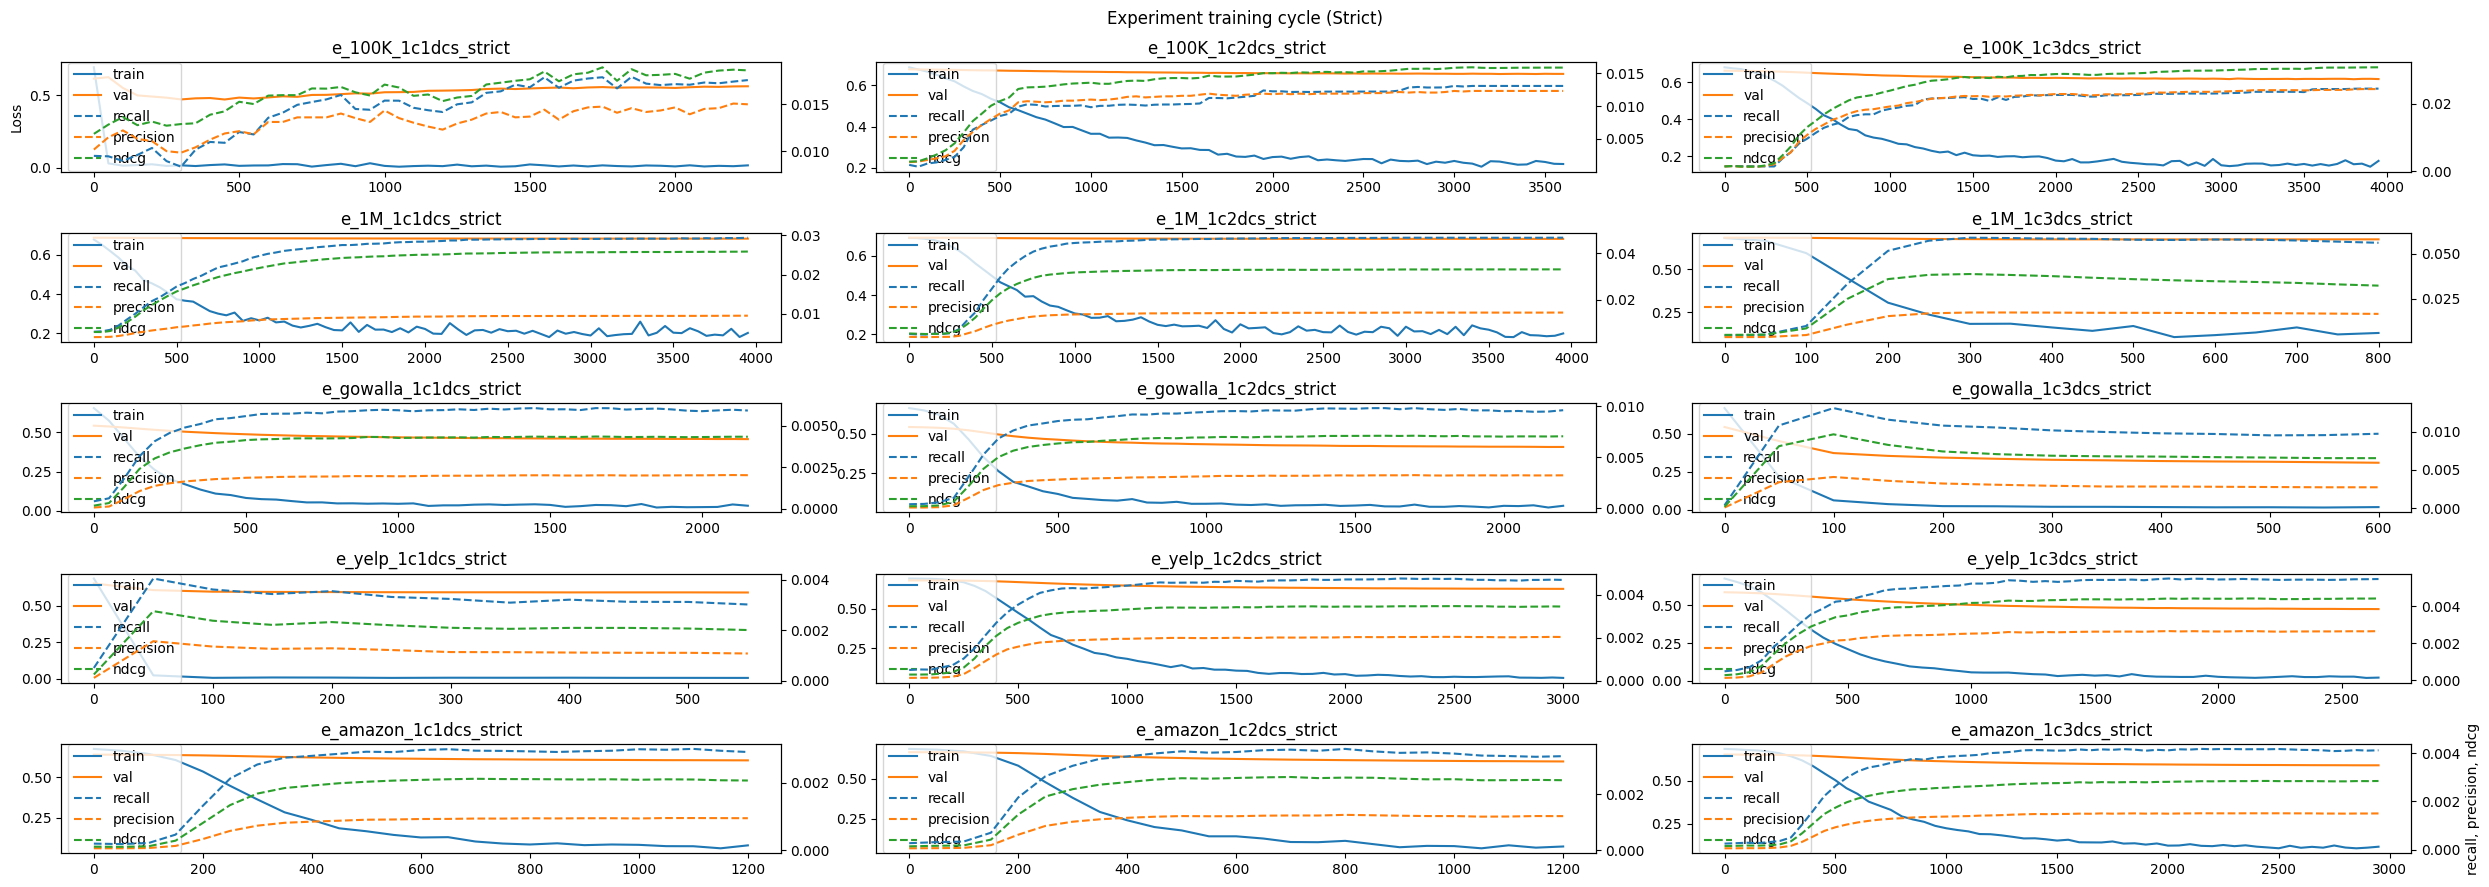

In [7]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
experiment_groups = df['experiment'].str.split('_').apply(lambda x: x[1]).unique()
total_exp= len(experiments_ran_non_strict)
plt.figure(figsize=(len(experiment_groups)*5,(total_exp//len(experiment_groups))*3))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(len(experiment_groups),total_exp//len(experiment_groups),i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
    
    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

plt.suptitle('Experiment training cycle (Strict)')
plt.tight_layout()
plt.savefig(version+'loss_metrics_strict.png')
plt.show()


## Losses for non-"Strict" DS and non-Random Runs

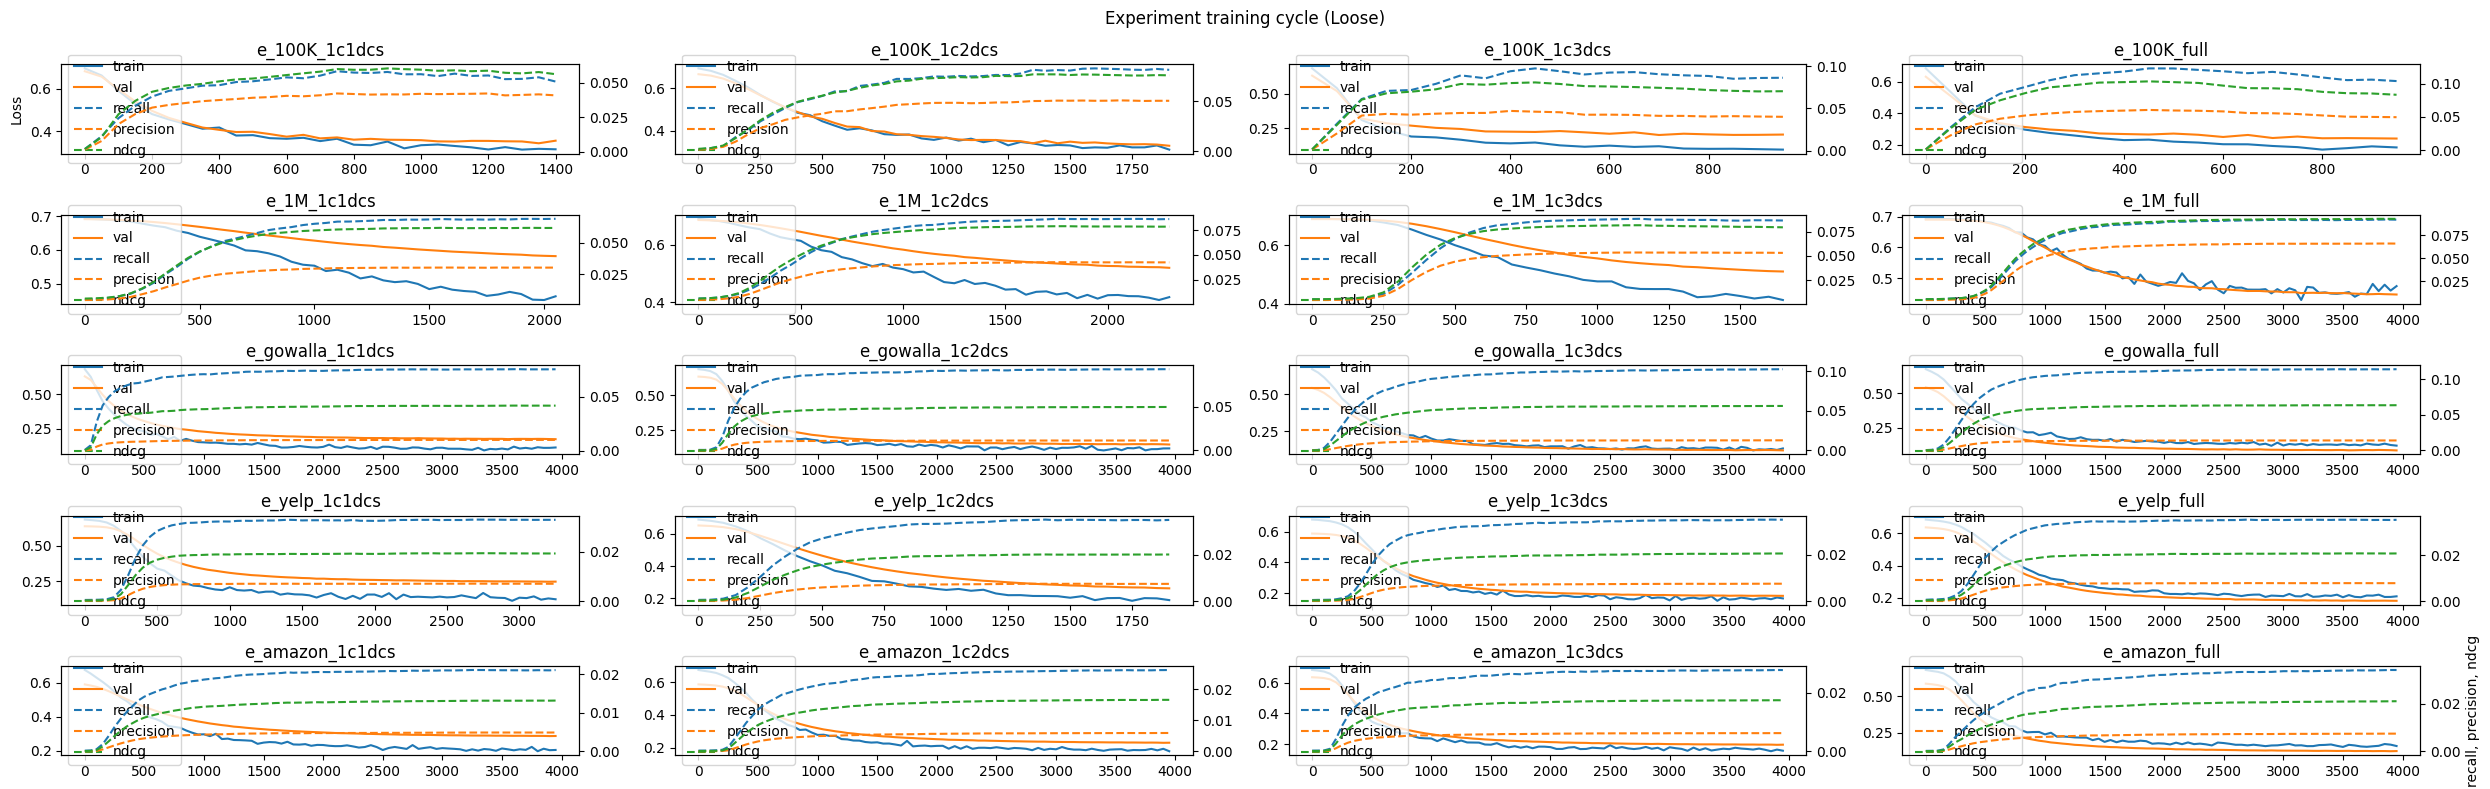

In [8]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
experiment_groups = df['experiment'].str.split('_').apply(lambda x: x[1]).unique()
total_exp= len(experiments_ran_non_strict)
plt.figure(figsize=(len(experiment_groups)*5,(total_exp//len(experiment_groups))*2))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(len(experiment_groups),total_exp//len(experiment_groups),i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.suptitle('Experiment training cycle (Loose)')
plt.tight_layout()
plt.savefig(version+'loss_metrics_loose.png')
plt.show()

## Random runs losses for non-strict runs

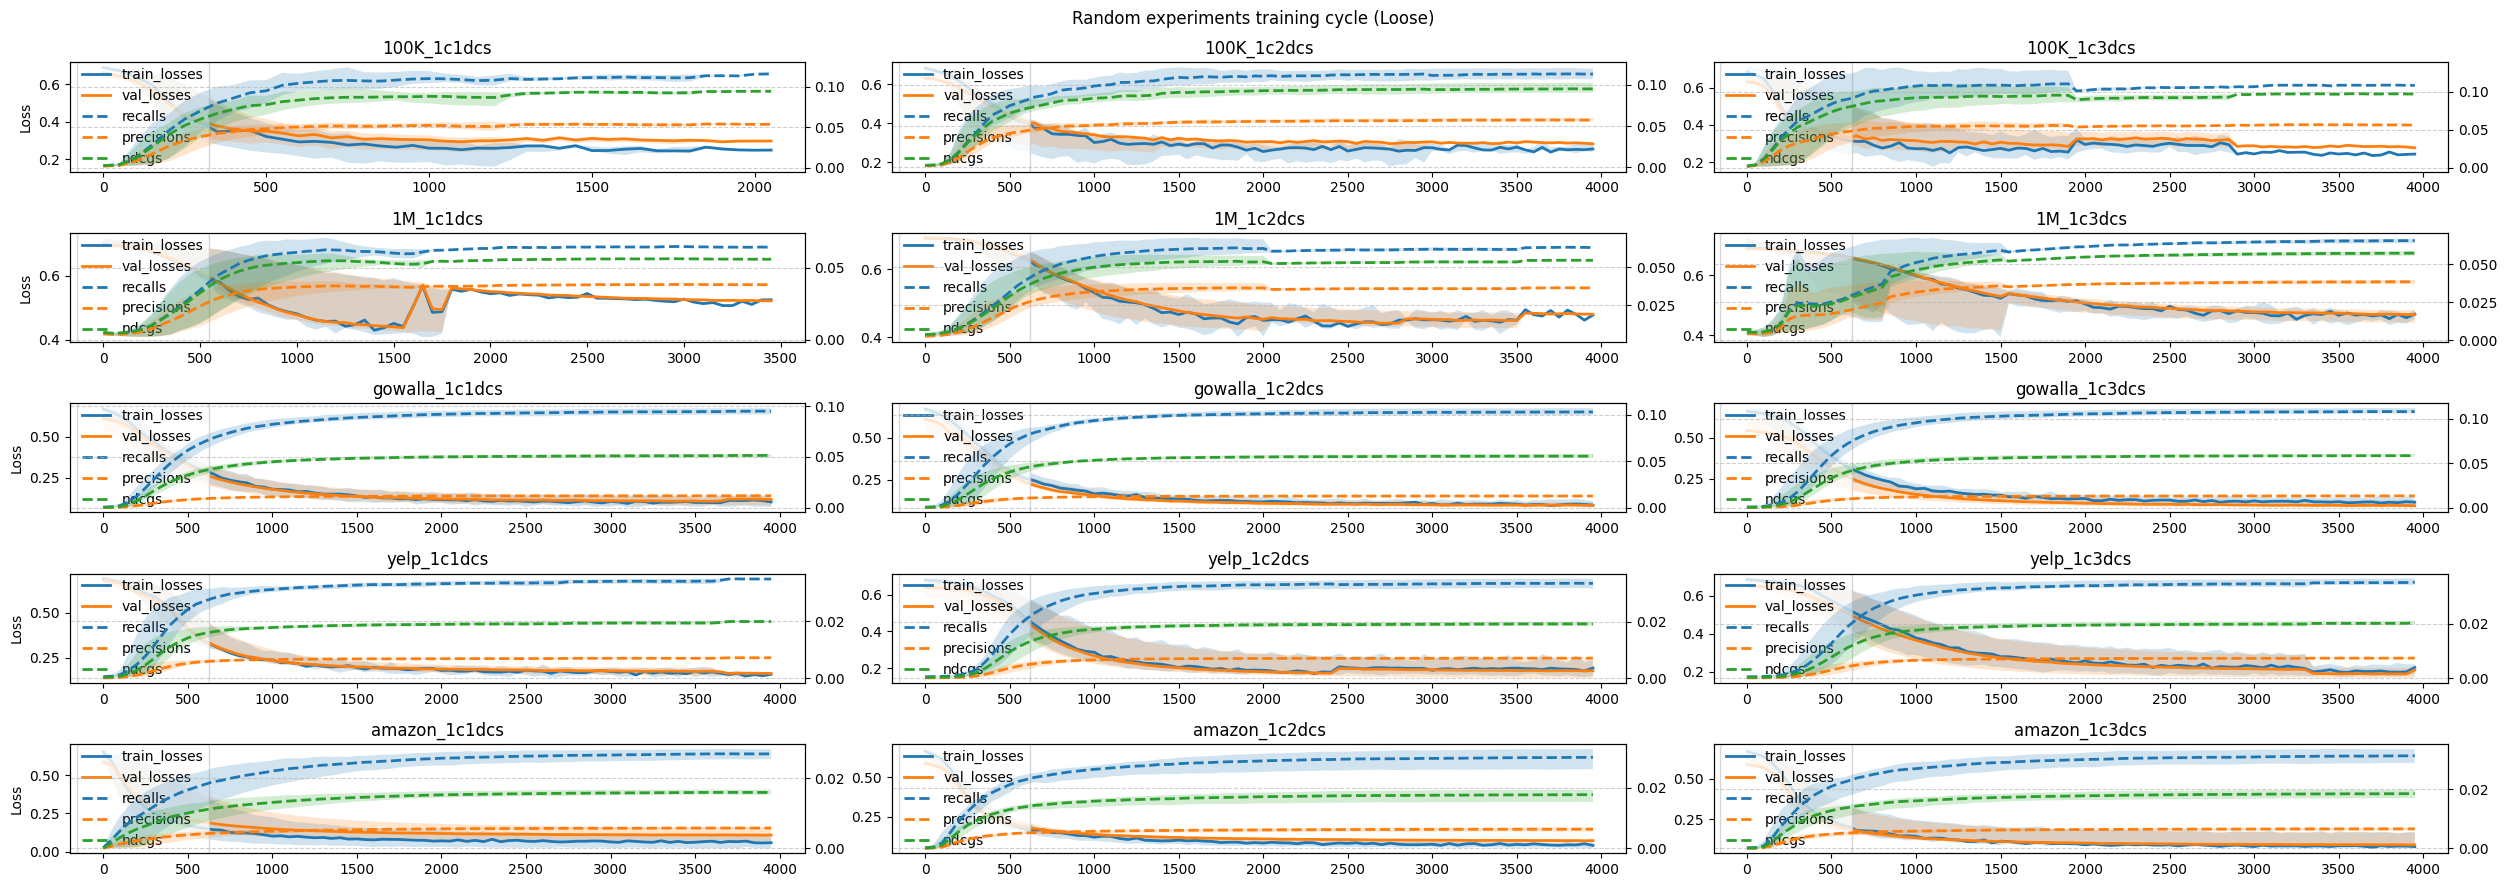

In [9]:
experiment_set = df[df['experiment'].str.contains('_rand') & ~df['experiment'].str.contains('_strict')]
experiments = experiment_set['experiment'].str.split('_').apply(lambda x: x[1]).unique()
experiments_ds = experiment_set['experiment'].str.split('_').apply(lambda x: x[2]).unique()

plt.figure(figsize=(len(experiments)*5, 3*len(experiments_ds)))
i=0
for experiment in experiments:
    for j, experiment_ds in enumerate(experiments_ds):
        new_df = experiment_set[experiment_set['experiment'].str.contains(experiment) & experiment_set['experiment'].str.contains(experiment_ds)]
        epochs_per_eval = new_df['epochs_per_eval'].unique()[0]
        max_len = new_df["train_losses"].apply(len).max()

        metrics_ax1 = ['train_losses', 'val_losses']
        metrics_ax2 = ['recalls', 'precisions', 'ndcgs']

        ax1= plt.subplot(len(experiments), len(experiments_ds),i+1)

        # 3. Pad shorter arrays with np.nan to match max_len
        for metric in metrics_ax1:
            padded_losses = [np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=np.nan,) for arr in new_df[metric]]

            # 4. Stack into a 2D matrix safely
            losses_matrix = np.vstack(padded_losses)

            # 5. Calculate aggregates using NaN-aware NumPy functions
            #mean_loss = np.nanmean(losses_matrix, axis=0)
            #std_loss = np.nanstd(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            epoch_axis = np.arange(max_len)*epochs_per_eval

            mean_loss = np.nanmedian(losses_matrix, axis=0)
            max_loss = np.nanmax(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            min_loss = np.nanmin(losses_matrix, axis=0)  # Standard deviation ignoring NaNs

            ax1.plot(epoch_axis, mean_loss, label=metric, lw=2) #color="blue", 
            ax1.fill_between(epoch_axis, max_loss, min_loss, alpha=0.2, ) #color="blue", 

        if j==0:
            plt.ylabel('Loss')

        ax2 = ax1.twinx()

        for metric in metrics_ax2:
            padded_losses = [np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=np.nan,) for arr in new_df[metric]]

            # 4. Stack into a 2D matrix safely
            losses_matrix = np.vstack(padded_losses)

            # 5. Calculate aggregates using NaN-aware NumPy functions
            #mean_loss = np.nanmean(losses_matrix, axis=0)
            #std_loss = np.nanstd(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            epoch_axis = np.arange(max_len)*epochs_per_eval

            mean_loss = np.nanmean(losses_matrix, axis=0)
            max_loss = np.nanmax(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            min_loss = np.nanmin(losses_matrix, axis=0)  # Standard deviation ignoring NaNs

            plt.plot(epoch_axis, mean_loss, label=metric, lw=2, linestyle='--') #color="blue", 
            plt.fill_between(epoch_axis, max_loss, min_loss, alpha=0.2,) #color="blue", 
        
        i+=1
    
    
        if j==len(experiments)-1:
            plt.ylabel(', '.join(x[:-1] for x in metrics_ax2))

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

        plt.title(f"{experiment}_{experiment_ds}")#, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.6)

plt.suptitle('Random experiments training cycle (Loose)')
plt.tight_layout()
plt.savefig(version+'loss_metrics_loose_rand.png')
plt.show()

## Random runs losses for strict runs

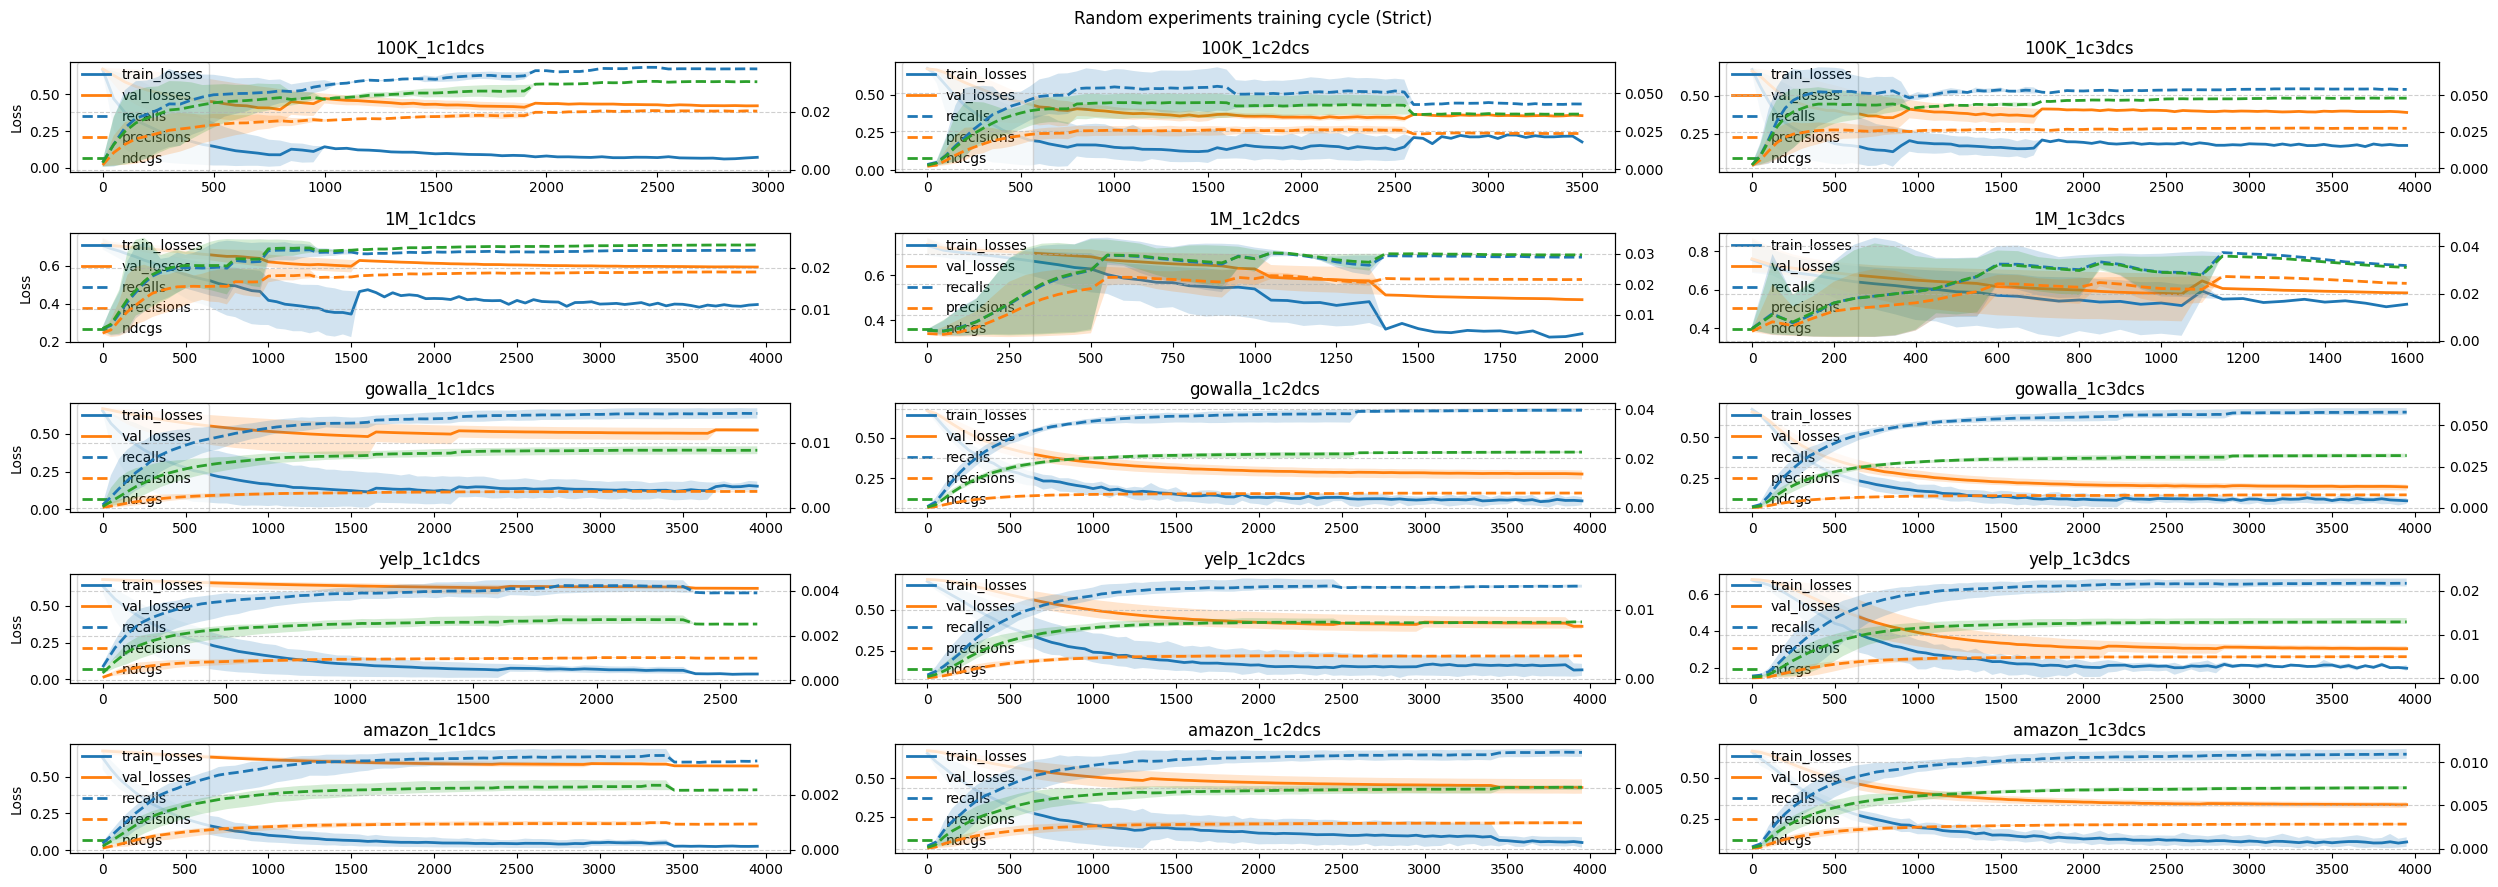

In [10]:
experiment_set = df[df['experiment'].str.contains('_rand') & df['experiment'].str.contains('_strict')]
experiments = experiment_set['experiment'].str.split('_').apply(lambda x: x[1]).unique()
experiments_ds = experiment_set['experiment'].str.split('_').apply(lambda x: x[2]).unique()

plt.figure(figsize=(len(experiments)*5, 3*len(experiments_ds)))
i=0
for experiment in experiments:
    for j, experiment_ds in enumerate(experiments_ds):
        new_df = experiment_set[experiment_set['experiment'].str.contains(experiment) & experiment_set['experiment'].str.contains(experiment_ds)]
        epochs_per_eval = new_df['epochs_per_eval'].unique()[0]
        max_len = new_df["train_losses"].apply(len).max()

        metrics_ax1 = ['train_losses', 'val_losses']
        metrics_ax2 = ['recalls', 'precisions', 'ndcgs']

        ax1= plt.subplot(len(experiments), len(experiments_ds),i+1)

        # 3. Pad shorter arrays with np.nan to match max_len
        for metric in metrics_ax1:
            padded_losses = [np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=np.nan,) for arr in new_df[metric]]

            # 4. Stack into a 2D matrix safely
            losses_matrix = np.vstack(padded_losses)

            # 5. Calculate aggregates using NaN-aware NumPy functions
            #mean_loss = np.nanmean(losses_matrix, axis=0)
            #std_loss = np.nanstd(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            epoch_axis = np.arange(max_len)*epochs_per_eval

            mean_loss = np.nanmean(losses_matrix, axis=0)
            max_loss = np.nanmax(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            min_loss = np.nanmin(losses_matrix, axis=0)  # Standard deviation ignoring NaNs

            ax1.plot(epoch_axis, mean_loss, label=metric, lw=2) #color="blue", 
            ax1.fill_between(epoch_axis, max_loss, min_loss, alpha=0.2, ) #color="blue", 

        if j==0:
            plt.ylabel('Loss')

        ax2 = ax1.twinx()

        for metric in metrics_ax2:
            padded_losses = [np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=np.nan,) for arr in new_df[metric]]

            # 4. Stack into a 2D matrix safely
            losses_matrix = np.vstack(padded_losses)

            # 5. Calculate aggregates using NaN-aware NumPy functions
            #mean_loss = np.nanmean(losses_matrix, axis=0)
            #std_loss = np.nanstd(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            epoch_axis = np.arange(max_len)*epochs_per_eval

            mean_loss = np.nanmean(losses_matrix, axis=0)
            max_loss = np.nanmax(losses_matrix, axis=0)  # Standard deviation ignoring NaNs
            min_loss = np.nanmin(losses_matrix, axis=0)  # Standard deviation ignoring NaNs

            plt.plot(epoch_axis, mean_loss, label=metric, lw=2, linestyle='--') #color="blue", 
            plt.fill_between(epoch_axis, max_loss, min_loss, alpha=0.2,) #color="blue", 
        
        i+=1
    
    
        if j==len(experiments)-1:
            plt.ylabel(', '.join(x[:-1] for x in metrics_ax2))

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

        plt.title(f"{experiment}_{experiment_ds}")#, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.6)

plt.suptitle('Random experiments training cycle (Strict)')
plt.tight_layout()
plt.savefig(version+'loss_metrics_strict_rand.png')
plt.show()

## Visualizations

In [11]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
train_features = ['best_recall','cycle','early_stopping'] if "best_recall" in df.columns else []
time_features = ['optim_time','train_time','infer_time'] + (['ds_time'] if "ds_time" in df.columns else [])
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features + train_features 
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment_grp'] = random_experiments_stats['experiment'].str.split('_').apply(lambda x: x[1])
random_experiments_stats['experiment_ds'] = random_experiments_stats['experiment'].str.split('_').apply(lambda x: x[2])
random_experiments_stats['experiment_strict'] = random_experiments_stats['experiment'].apply(lambda x: 'strict' if 'strict' in x else '')
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].str.split('_').apply(lambda x: x[2]) + random_experiments_stats['experiment'].apply(lambda x: '_rand' if 'rand' in x else '')
random_experiments_stats['ds_level'] = random_experiments_stats['experiment'].apply(lambda x: x[2] if 'dcs' in x else 'f')

for i, row in random_experiments_stats.iterrows():
    random_experiments_stats.loc[i,'ds_users'] = users_map_train[row['experiment_grp']] if row['experiment_ds'] == 'full' else row['ds_users']
    random_experiments_stats.loc[i,'ds_items'] = items_map_train[row['experiment_grp']] if row['experiment_ds'] == 'full' else row['ds_items']

random_experiments_stats['nodes'] = random_experiments_stats['ds_users'] + random_experiments_stats['ds_items']
#random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
color_dict = { exp:color_map[exp[0:4]] for exp in random_experiments_stats['experiment'].unique()}
random_experiments_stats.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,experiment_grp,experiment_ds,experiment_strict,ds_level,nodes
0,1c1dcs,0.346382,0.050714,0.040738,0.056046,0.349949,0.056923,0.046885,0.063436,0.057651,900,True,2111.864472,4.238313,0.090695,20.437767,65267,303.0,232.0,1,64,0.000513,0.002743,2427,RMSprop,100K,1c1dcs,,1,535.0
1,1c1dcs_rand,0.283489,0.106351,0.050820,0.089819,0.279020,0.116738,0.057131,0.097914,0.108118,1300,True,1960.147073,5.591445,0.095832,NaN,65267,NaN,NaN,1,128,0.000505,0.000129,1510,RMSprop,100K,1c1dcs,,1,NaN
2,1c1dcs_rand,0.264115,0.115966,0.051066,0.086456,0.258695,0.117847,0.054836,0.097500,0.123866,750,True,1973.238387,4.726929,0.096753,NaN,65267,NaN,NaN,1,256,0.000520,0.000353,2386,Adam,100K,1c1dcs,,1,NaN
3,1c1dcs_rand,0.240874,0.101410,0.045246,0.075709,0.244935,0.105243,0.048689,0.082482,0.117954,700,True,2169.676961,4.408539,0.096935,NaN,65267,NaN,NaN,1,256,0.000664,0.000009,2183,Adam,100K,1c1dcs,,1,NaN
4,1c1dcs_rand,0.290651,0.115740,0.053525,0.094265,0.299438,0.108752,0.054590,0.091426,0.115133,1550,True,2011.061679,6.392260,0.095547,NaN,65267,NaN,NaN,1,128,0.000413,0.000049,1834,Adam,100K,1c1dcs,,1,NaN


In [12]:
total_run = random_experiments_stats[time_features].sum().sum()
print('Total run time: ', str(datetime.timedelta(seconds=total_run)))

Total run time:  55 days, 20:06:32.871538


In [13]:
full_cds = random_experiments_stats[~random_experiments_stats['experiment'].str.contains('_rand')]

#for i, row in full_cds.iterrows():
#    full_cds.loc[i,'ds_users'] = users_map_train[row['experiment_grp']] if row['experiment_ds'] == 'full' else row['ds_users']
#    full_cds.loc[i,'ds_items'] = items_map_train[row['experiment_grp']] if row['experiment_ds'] == 'full' else row['ds_items']

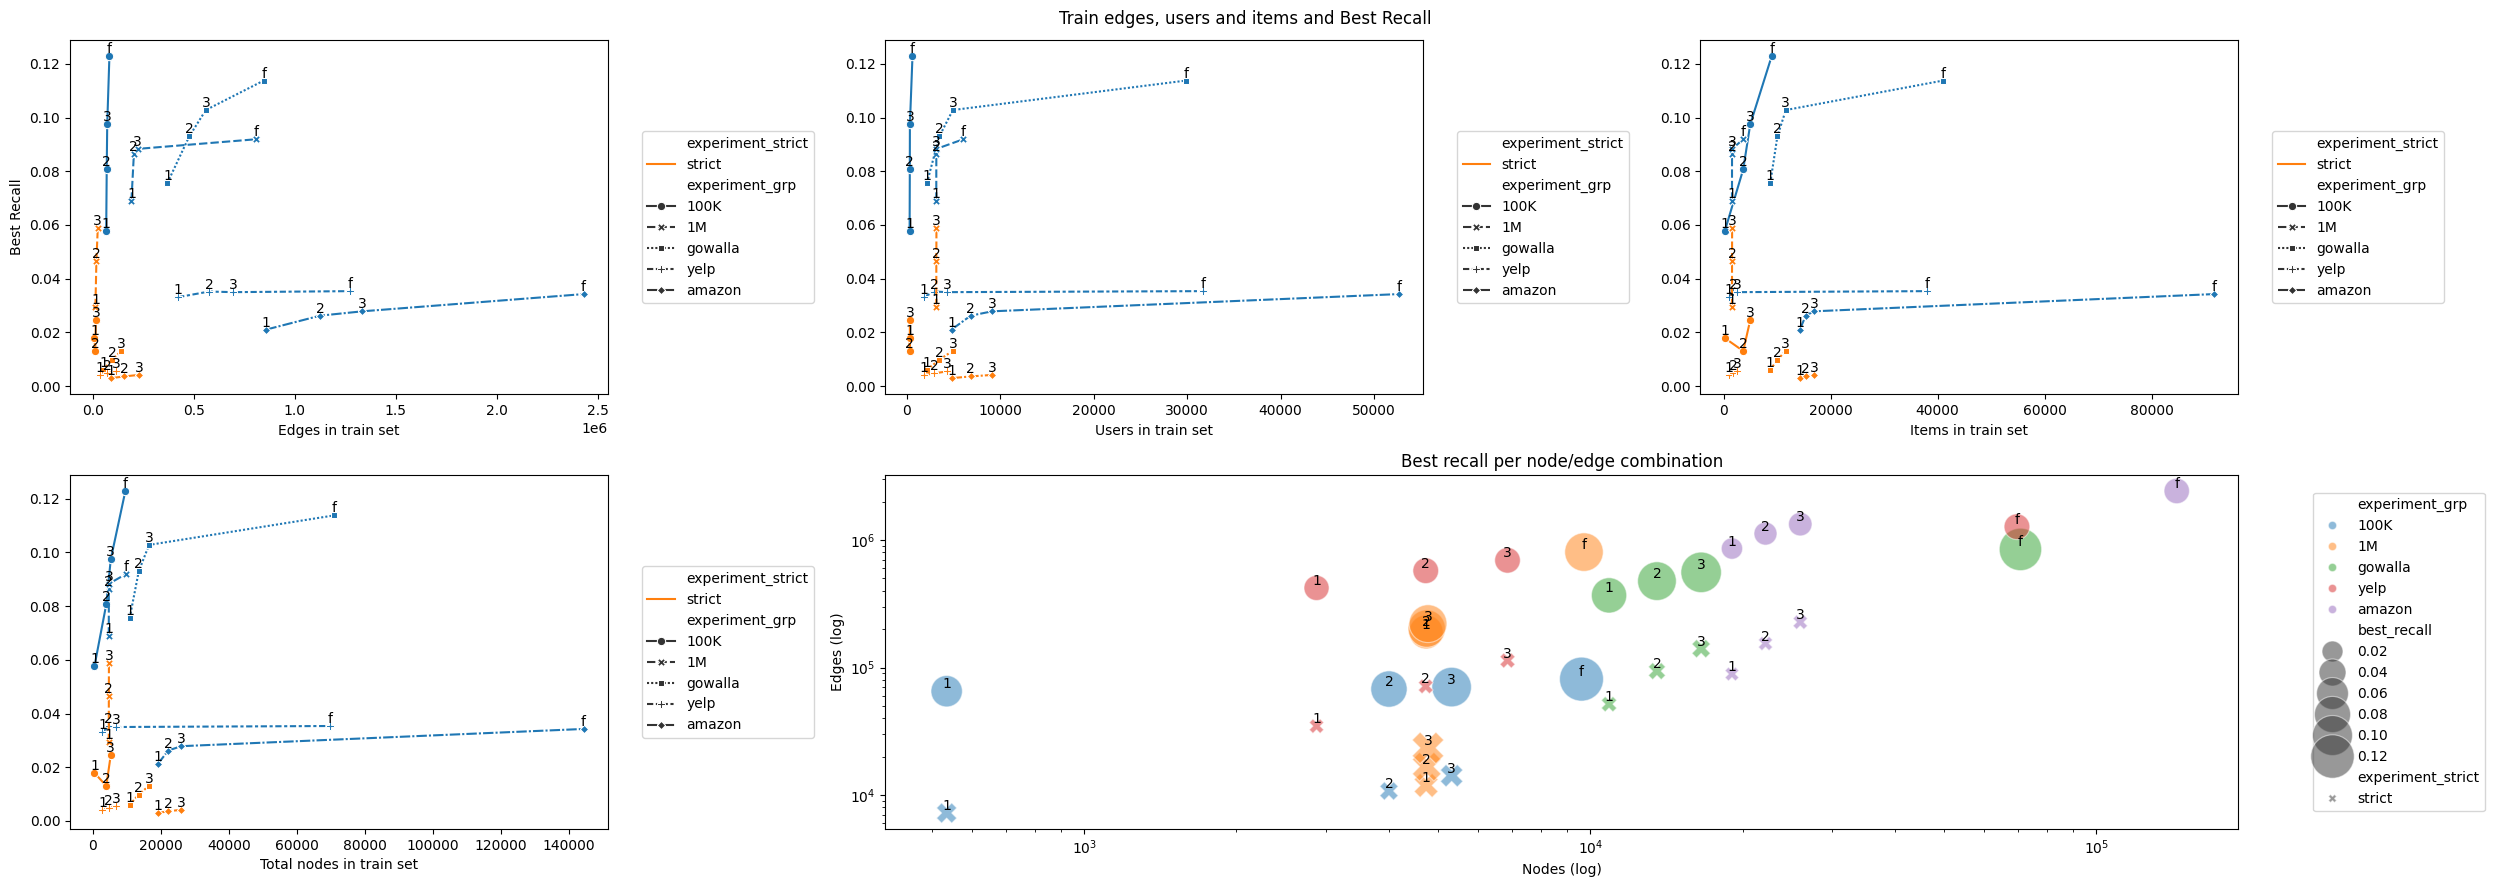

In [14]:
#full_cds = random_experiments_stats[~random_experiments_stats['experiment'].str.contains('_rand')]
metric = 'best_recall'
ylab = 'Best Recall'
plt.figure(figsize=(25,9))

plot_height = 2
plot_width = 3

plt.subplot(plot_height,plot_width,1)
ax = sns.lineplot(data=full_cds, x='train_edges', y=metric, hue='experiment_strict', style='experiment_grp', markers=True)
for i, row in full_cds.iterrows():
    ax.text(row['train_edges'], row[metric], row['ds_level'], ha='center', va='bottom')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.ylabel(ylab)
plt.xlabel('Edges in train set')

plt.subplot(plot_height,plot_width,2)
ax = sns.lineplot(data=full_cds, x='ds_users', y=metric, hue='experiment_strict', style='experiment_grp', markers=True)
for i, row in full_cds.iterrows():
    ax.text(row['ds_users'], row[metric], row['ds_level'], ha='center', va='bottom')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.ylabel('')
plt.xlabel('Users in train set')

plt.subplot(plot_height,plot_width,3)
ax = sns.lineplot(data=full_cds, x='ds_items', y=metric, hue='experiment_strict', style='experiment_grp', markers=True)
for i, row in full_cds.iterrows():
    ax.text(row['ds_items'], row[metric], row['ds_level'], ha='center', va='bottom')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.ylabel('')
plt.xlabel('Items in train set')

plt.subplot(plot_height,plot_width,4)
#full_cds[full_cds['experiment_strict']=='']

ax = sns.lineplot(data=full_cds, x='nodes', y=metric, hue='experiment_strict', style='experiment_grp', markers=True)
for i, row in full_cds.iterrows():
    ax.text(row['nodes'], row[metric], row['ds_level'], ha='center', va='bottom')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.ylabel('')
plt.xlabel('Total nodes in train set')

plt.subplot(plot_height,plot_width,(5,6))
ax = sns.scatterplot(data=full_cds, y='train_edges', x='nodes', size=metric, hue='experiment_grp',style='experiment_strict',sizes=(100, 1000), alpha=0.5)
plt.title('Best recall per node/edge combination')
for i, row in full_cds.iterrows():
    ax.text(y=row['train_edges'], x=row['nodes'], s=row['ds_level'], ha='center', va='bottom')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.ylabel('Edges (log)')
plt.xlabel('Nodes (log)')
plt.xscale('log')
plt.yscale('log')

plt.suptitle(f'Train edges, users and items and {ylab}')
plt.tight_layout()
plt.savefig(version+'edges_users_items.png')
plt.show()

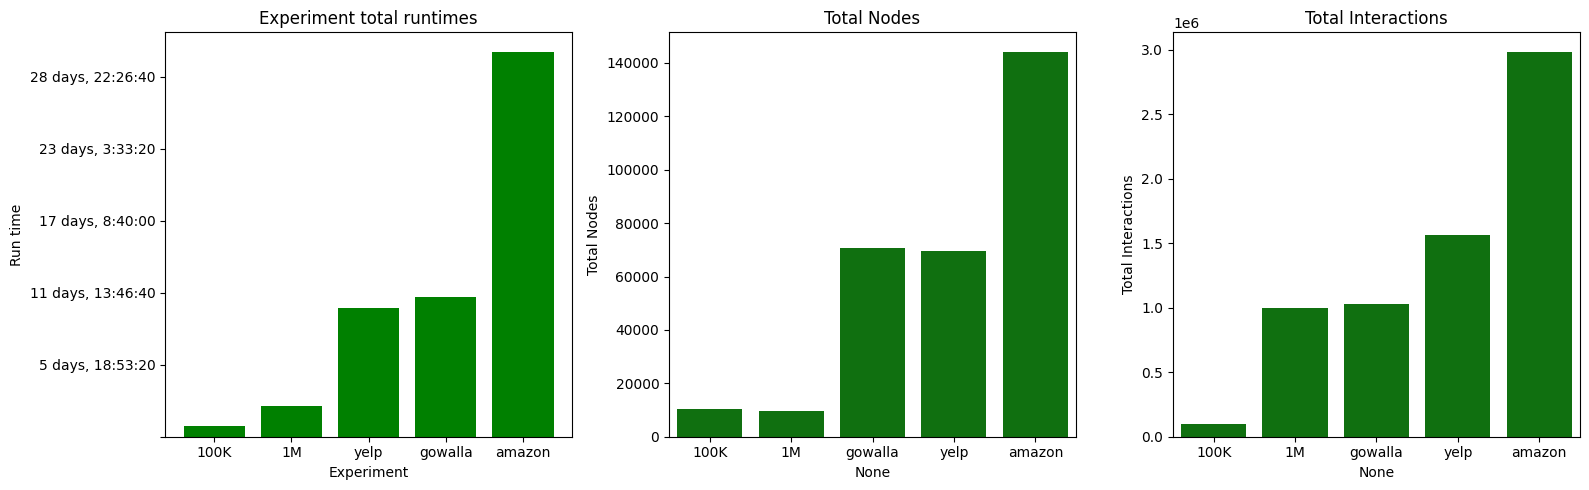

In [19]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta

def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

plt.figure(figsize=(16,5))
plt.subplot(1,3,1)

run_times = random_experiments_stats.groupby('experiment_grp').sum().sort_values(time_features)[time_features].sum(axis=1)
plt.bar(x=run_times.index, height=run_times.values, color='green')
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))
plt.title('Experiment total runtimes')
plt.ylabel('Run time')
plt.xlabel('Experiment')

subset_df = total_numbers #.drop('amazon', axis=0)

plt.subplot(1,3,2)
x_labels = total_numbers.index
x_ticks = np.arange(len(x_labels))
ax = sns.barplot(x=subset_df.index, y=subset_df.total_nodes, color='green')
ax.set_ylabel('Total Nodes')
plt.title('Total Nodes')
#ax2 = ax.twinx()

plt.subplot(1,3,3)

sns.barplot(x=subset_df.index, y=subset_df.total_interactions, color='green', )
plt.ylabel('Total Interactions')
plt.title('Total Interactions')

plt.tight_layout()
plt.savefig(version+'total_run_time.png')
plt.show()

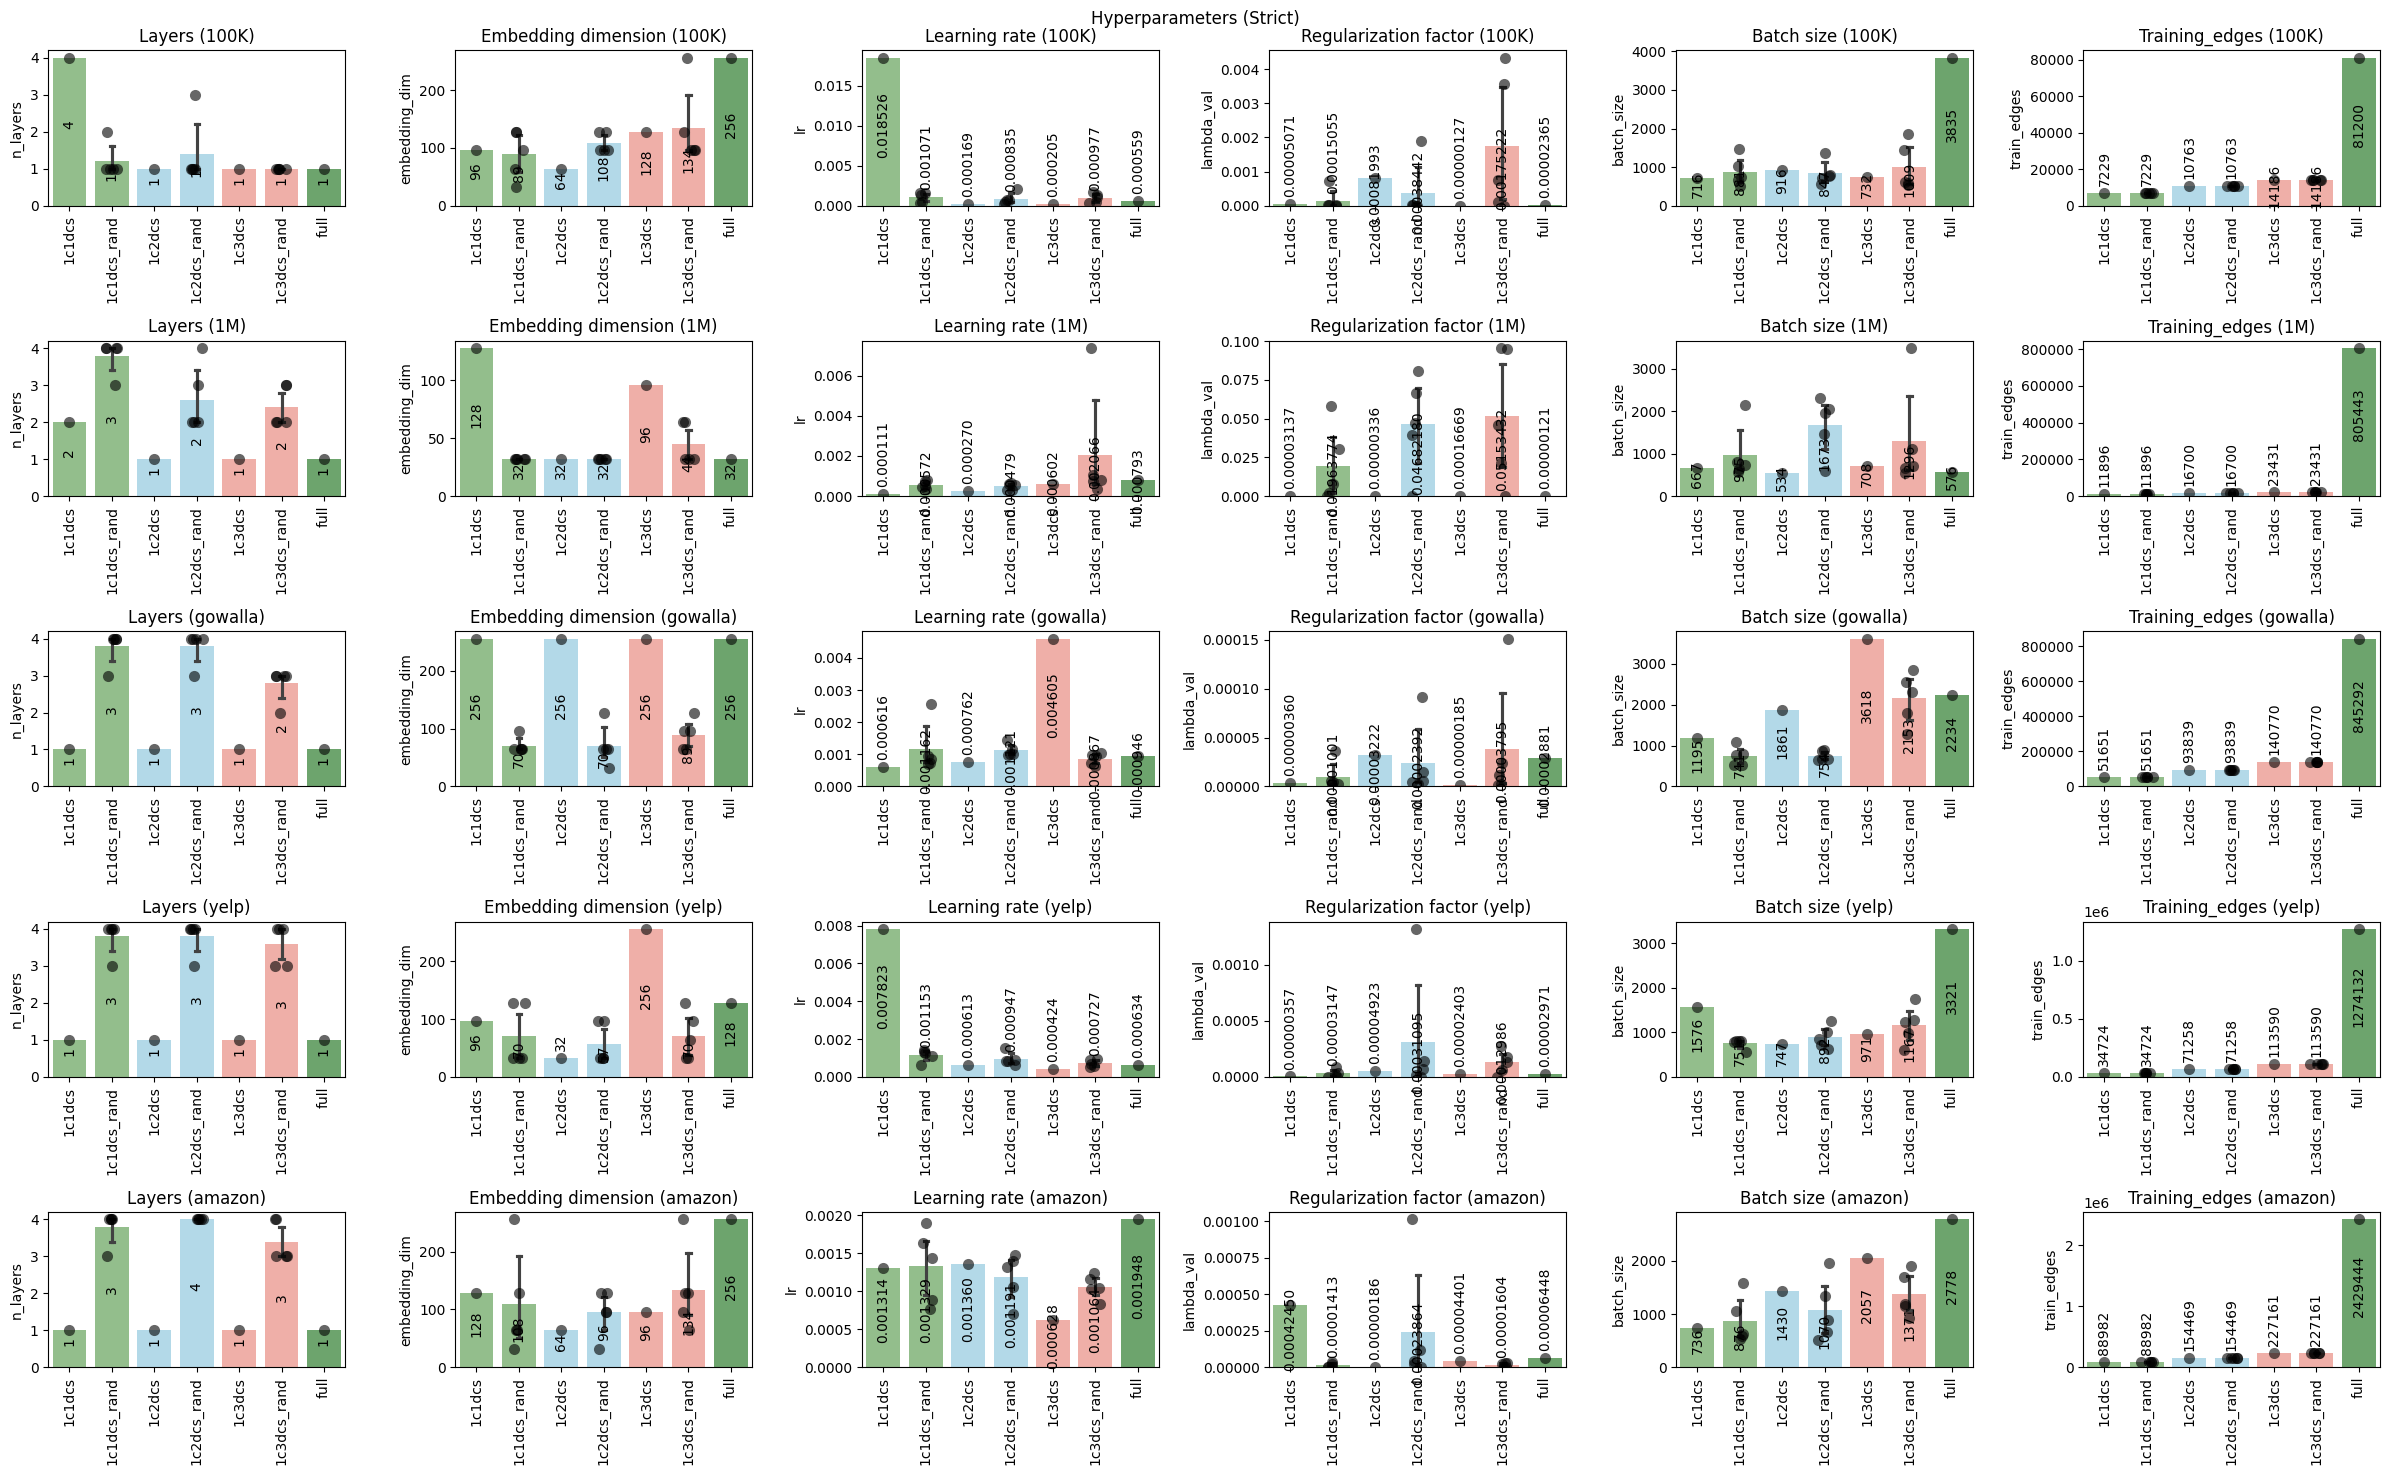

In [20]:
plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = random_experiments_stats['experiment_grp'].nunique()
n_plots_wide = len(plots)

plt.figure(figsize=(n_plots_wide*4,n_plots_height*3))

cols = ['n_layers','embedding_dim','lr','batch_size']

for j,group in enumerate(random_experiments_stats['experiment_grp'].unique()):
    for i,metric in enumerate(plots):
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment_grp'] == group) & ((random_experiments_stats['experiment_strict']=='strict')  | (random_experiments_stats['experiment']=='full')) ] # 
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)

        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        plt.title(titles[i]+f' ({group})')
        plt.xlabel('')
        plt.xticks(rotation=90)

plt.suptitle('Hyperparameters (Strict)')
plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters_strict.png')
plt.show()

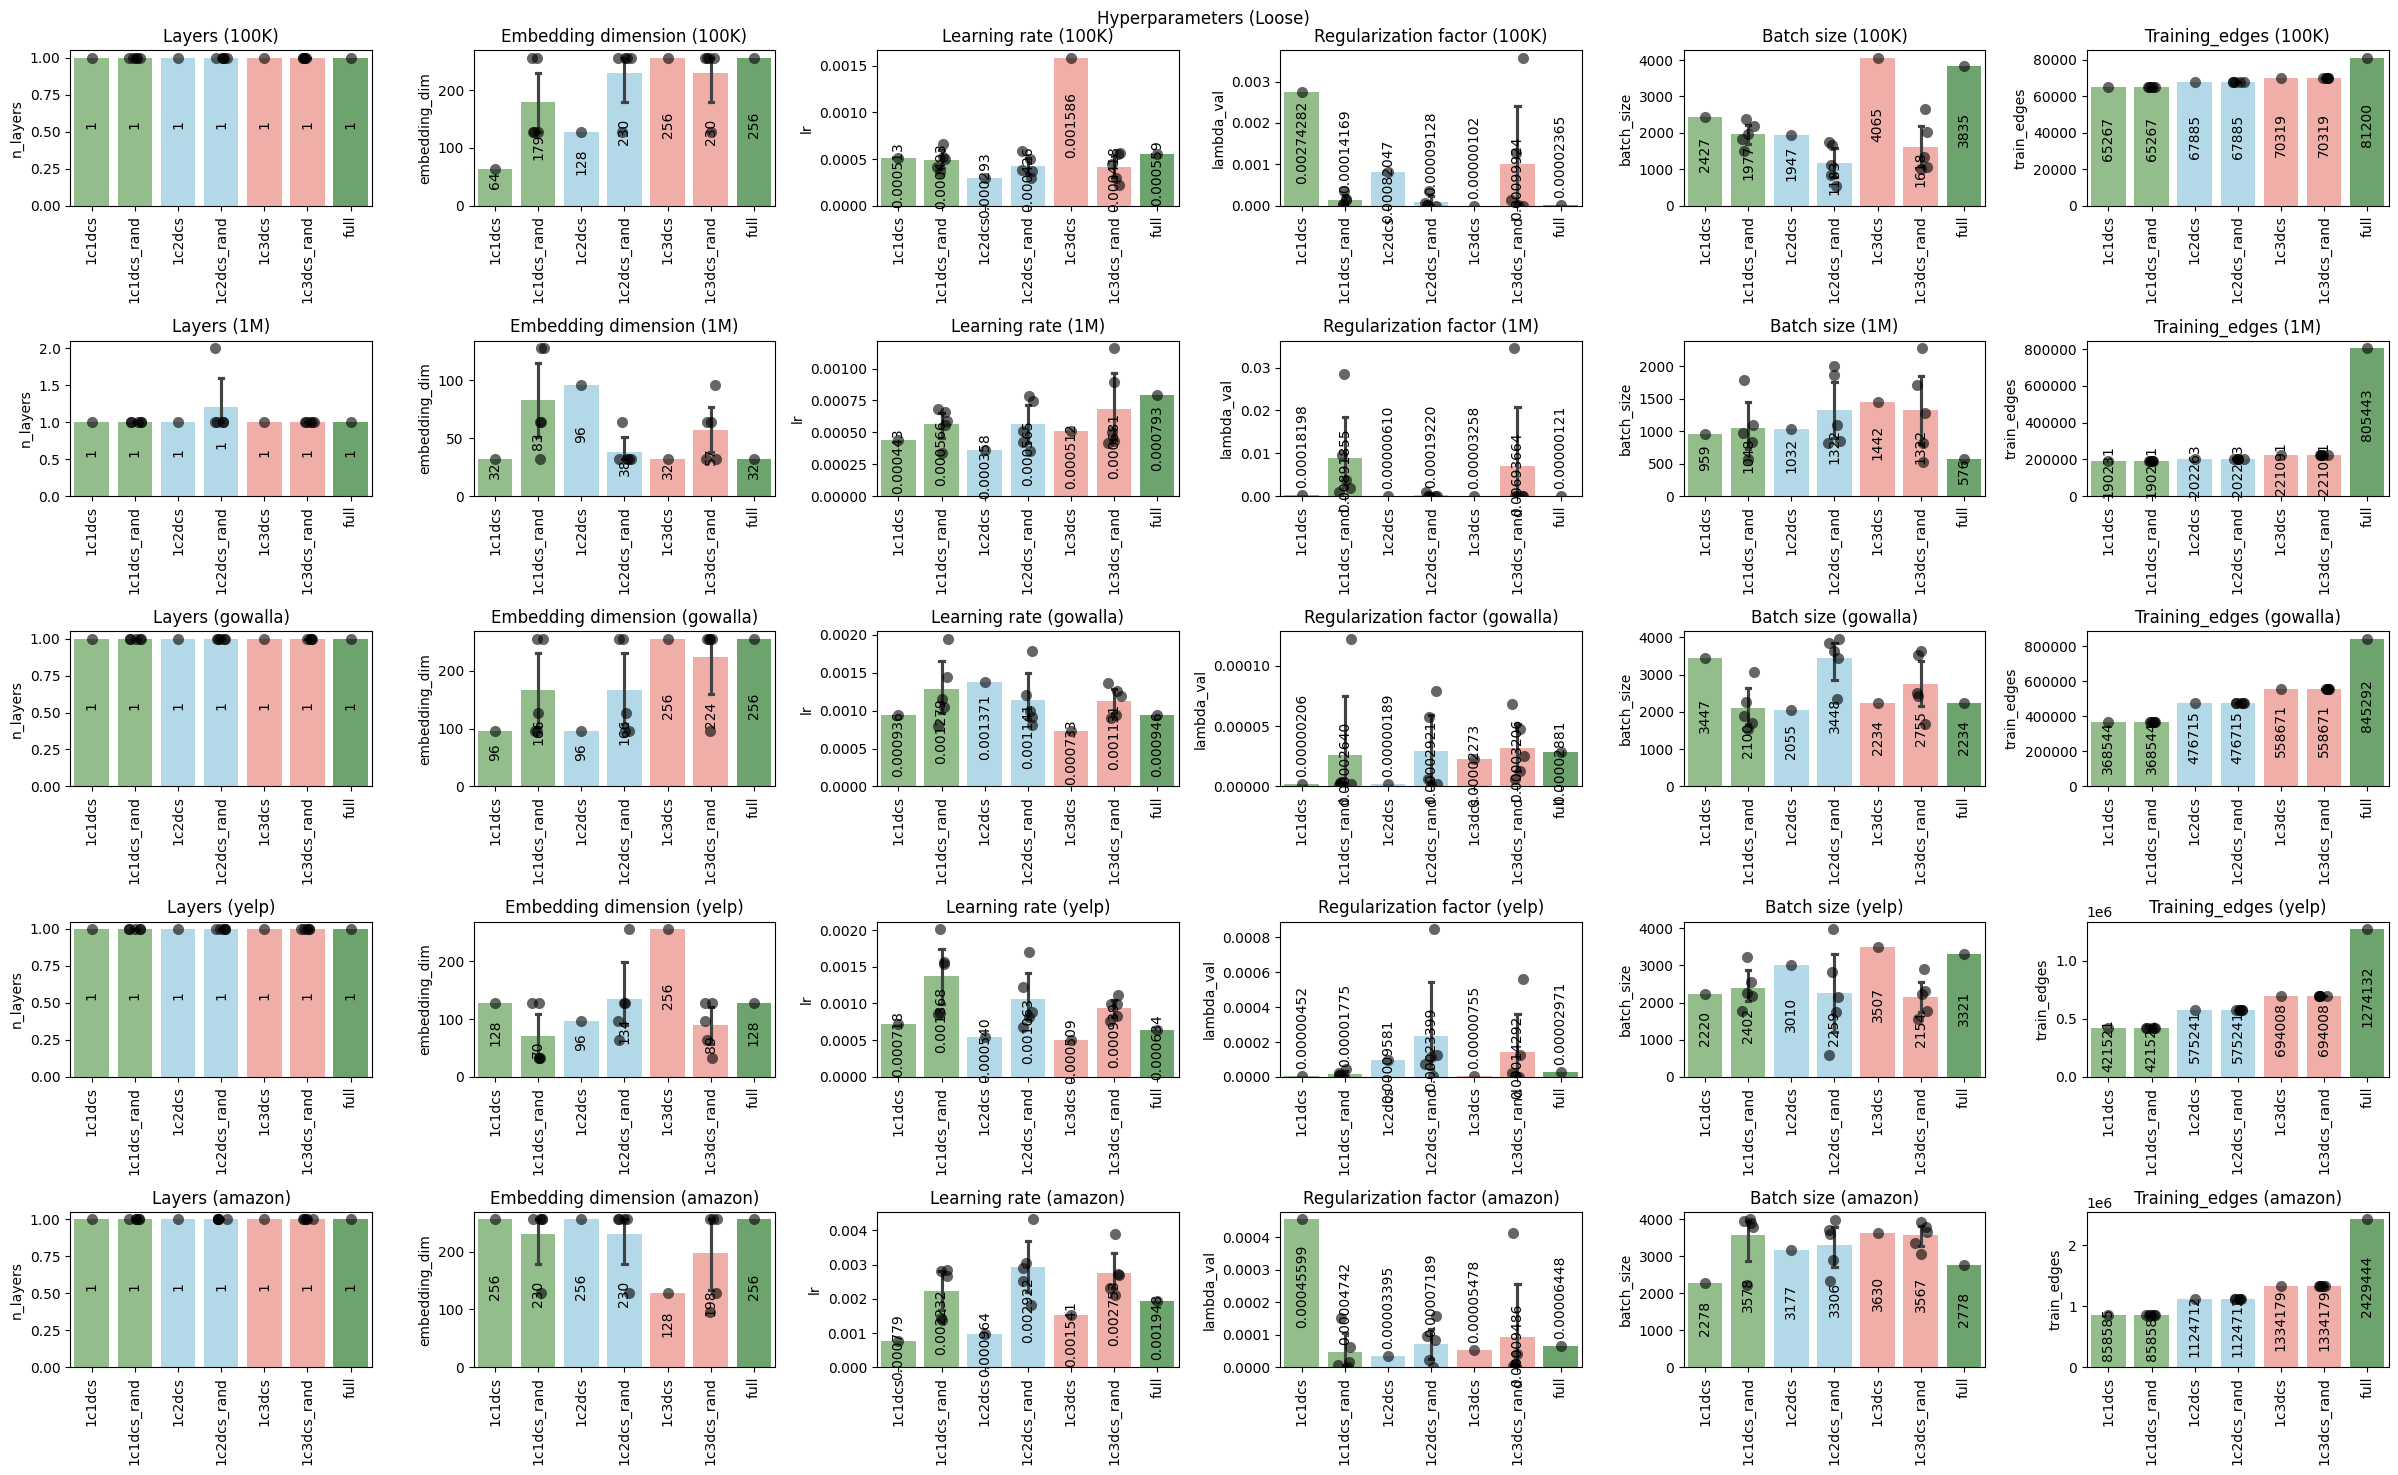

In [21]:
plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = random_experiments_stats['experiment_grp'].nunique()
n_plots_wide = len(plots)

plt.figure(figsize=(n_plots_wide*4,n_plots_height*3))

cols = ['n_layers','embedding_dim','lr','batch_size']

for j,group in enumerate(random_experiments_stats['experiment_grp'].unique()):
    for i,metric in enumerate(plots):
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment_grp'] == group) & ((random_experiments_stats['experiment_strict']=='')  | (random_experiments_stats['experiment']=='full')) ] # 
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)

        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        plt.title(titles[i]+f' ({group})')
        plt.xlabel('')
        plt.xticks(rotation=90)

plt.suptitle('Hyperparameters (Loose)')
plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()

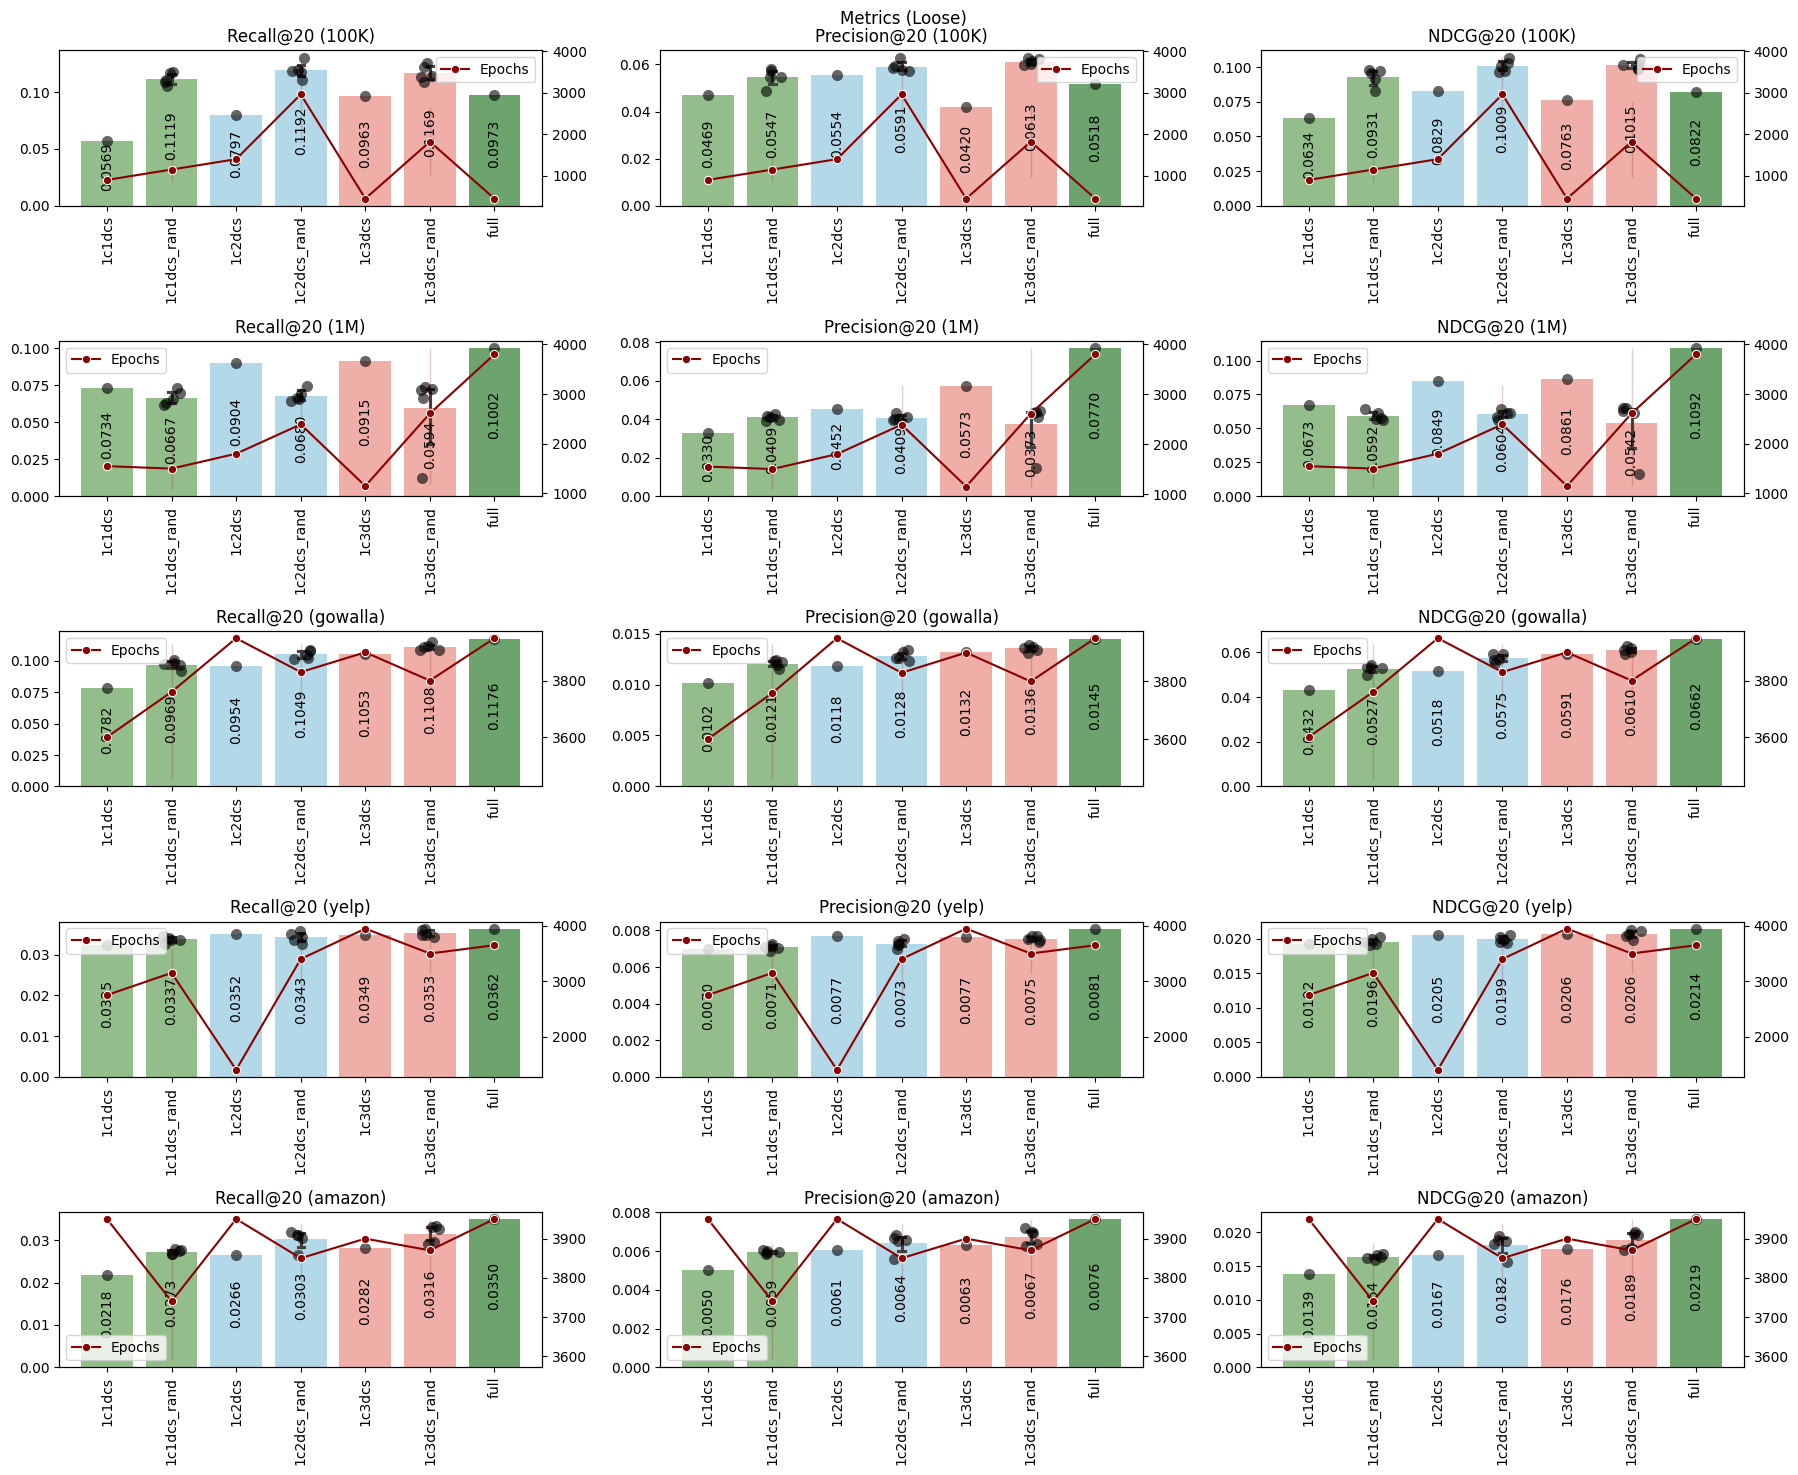

In [22]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

n_plots_height = random_experiments_stats['experiment_grp'].nunique()
n_plots_wide = len(plots)

plt.figure(figsize=(n_plots_wide*6,n_plots_height*3))
#plt.figure(figsize=(20,5))

for j,group in enumerate(random_experiments_stats['experiment_grp'].unique()):

    for i,metric in enumerate(plots):
        #plt.subplot(1,len(plots),i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment_grp'] == group) & ((random_experiments_stats['experiment_strict']=='')  | (random_experiments_stats['experiment']=='full')) ] 
        
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(rotation=90)

        ax2 = ax.twinx()
        #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
        if 'cycle' in subset_df.columns:
            sns.lineplot(data=subset_df, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
            ax2.set_ylabel('Training epochs')

        plt.title(titles[i]+f' ({group})')
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)

plt.suptitle('Metrics (Loose)')
plt.tight_layout()
plt.savefig(version+'experiments_metrics.png')
plt.show()

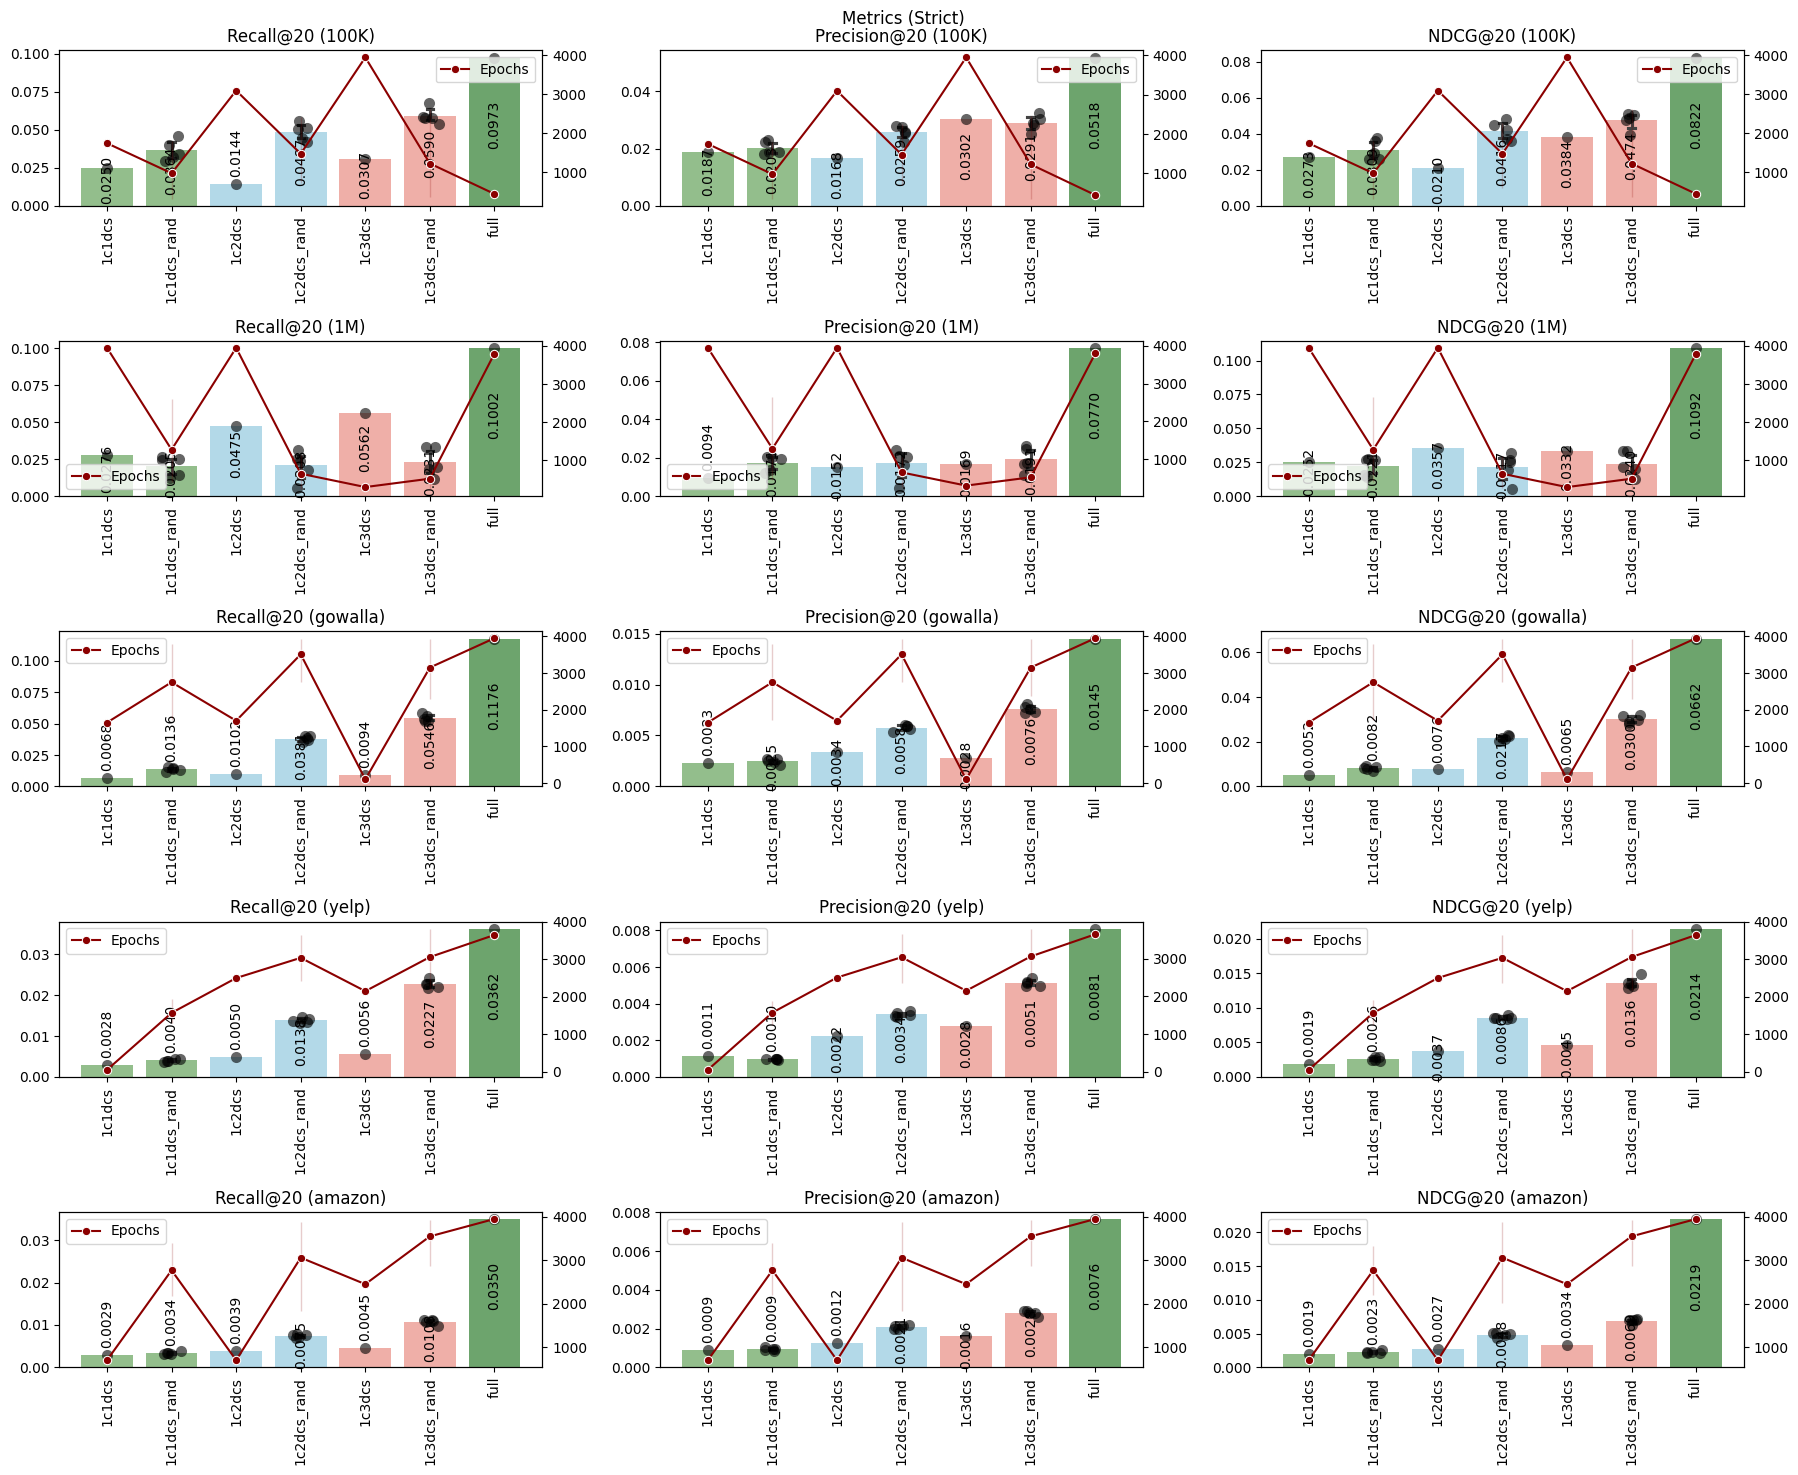

In [23]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

n_plots_height = random_experiments_stats['experiment_grp'].nunique()
n_plots_wide = len(plots)

plt.figure(figsize=(n_plots_wide*6,n_plots_height*3))
#plt.figure(figsize=(20,5))

for j,group in enumerate(random_experiments_stats['experiment_grp'].unique()):

    for i,metric in enumerate(plots):
        #plt.subplot(1,len(plots),i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment_grp'] == group) & ((random_experiments_stats['experiment_strict']=='strict')  | (random_experiments_stats['experiment']=='full')) ] 
        
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(rotation=90)

        ax2 = ax.twinx()
        #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
        if 'cycle' in subset_df.columns:
            sns.lineplot(data=subset_df, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
            ax2.set_ylabel('Training epochs')

        plt.title(titles[i]+f' ({group})')
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)

plt.suptitle('Metrics (Strict)')
plt.tight_layout()
plt.savefig(version+'experiments_metrics_strict.png')
plt.show()

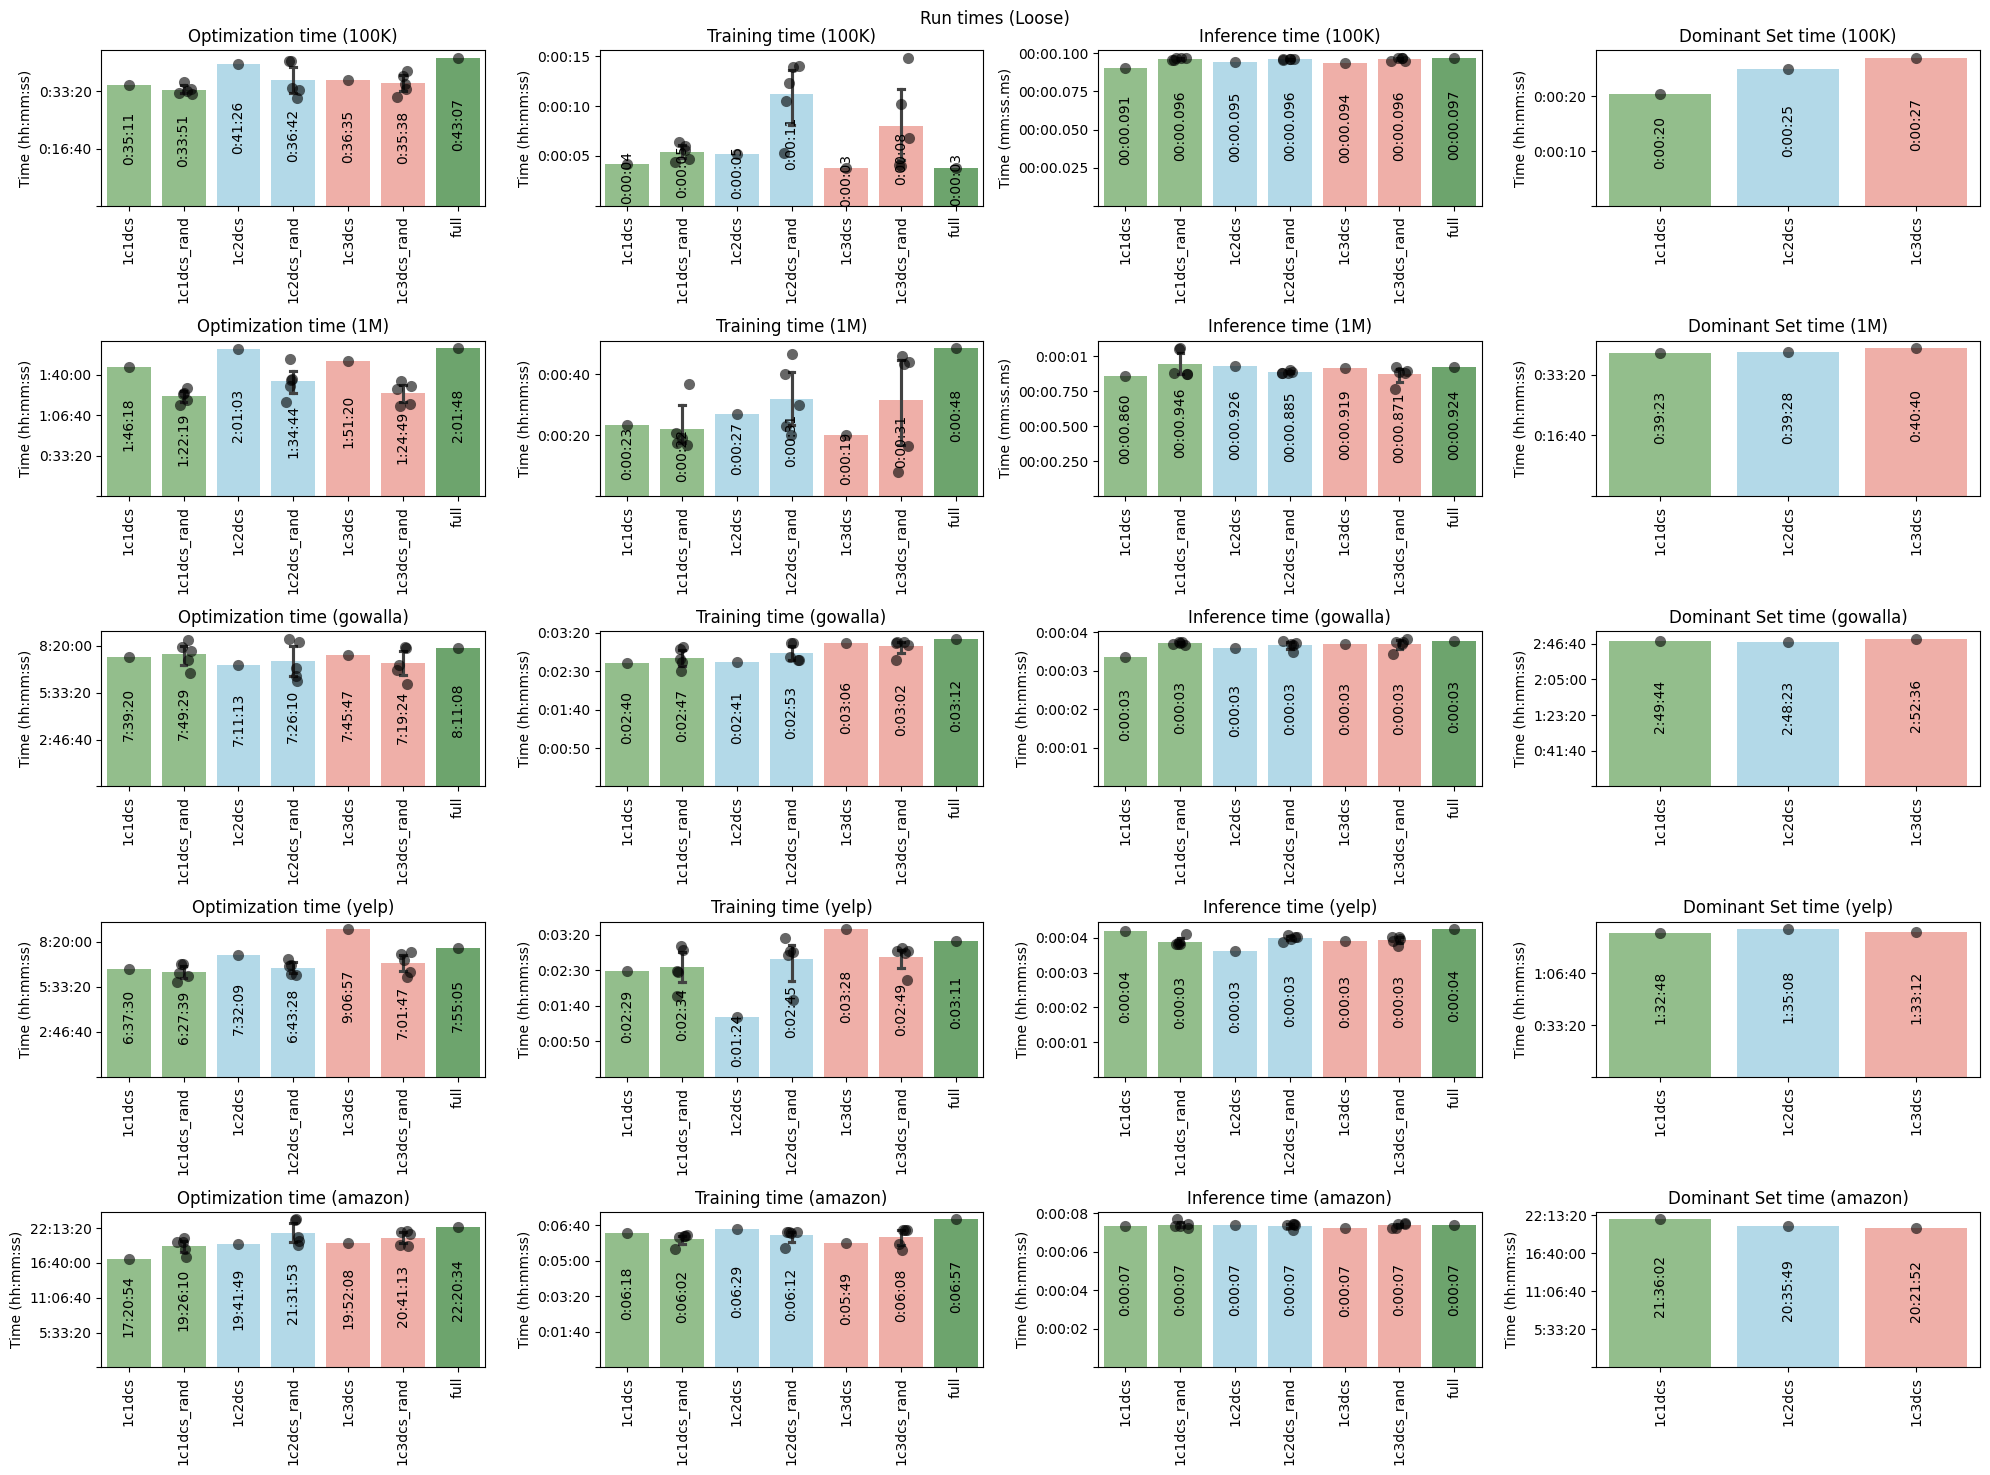

In [24]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

n_plots_height = random_experiments_stats['experiment_grp'].nunique()
n_plots_wide = len(plots)
plt.figure(figsize=(n_plots_wide*5,n_plots_height*3))

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for j,group in enumerate(random_experiments_stats['experiment_grp'].unique()):
    for i, metric in enumerate(plots):
        #plt.subplot(n_plots_height, n_plots_wide, i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment_grp'] == group) & ((random_experiments_stats['experiment_strict']=='')  | (random_experiments_stats['experiment']=='full')) ] 

        # Create the barplot
        ax = sns.barplot(data=subset_df[subset_df[metric]>0], x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict, hue='experiment', legend=False) 
        # Iterate through all containers generated by Seaborn's hue
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            # Generate a label list directly from the bar heights in this specific container
            labels = [format_time(val) for val in container.datavalues]
            ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)

        # Add the stripplot
        sns.stripplot(data=subset_df[subset_df[metric]>0], x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15, ax=ax)
        
        plt.title(titles[i]+f' ({group})')
        plt.xlabel('')
        plt.xticks(rotation=90)

        # Use the mean of the actual current metric to decide the axis label
        current_mean = subset_df[metric].mean()
        if current_mean < 1:
            plt.ylabel('Time (mm:ss.ms)')
        else:
            plt.ylabel('Time (hh:mm:ss)')
            
        plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.suptitle('Run times (Loose)')
plt.tight_layout()
plt.savefig(version+'experiments_times.png')
plt.show()

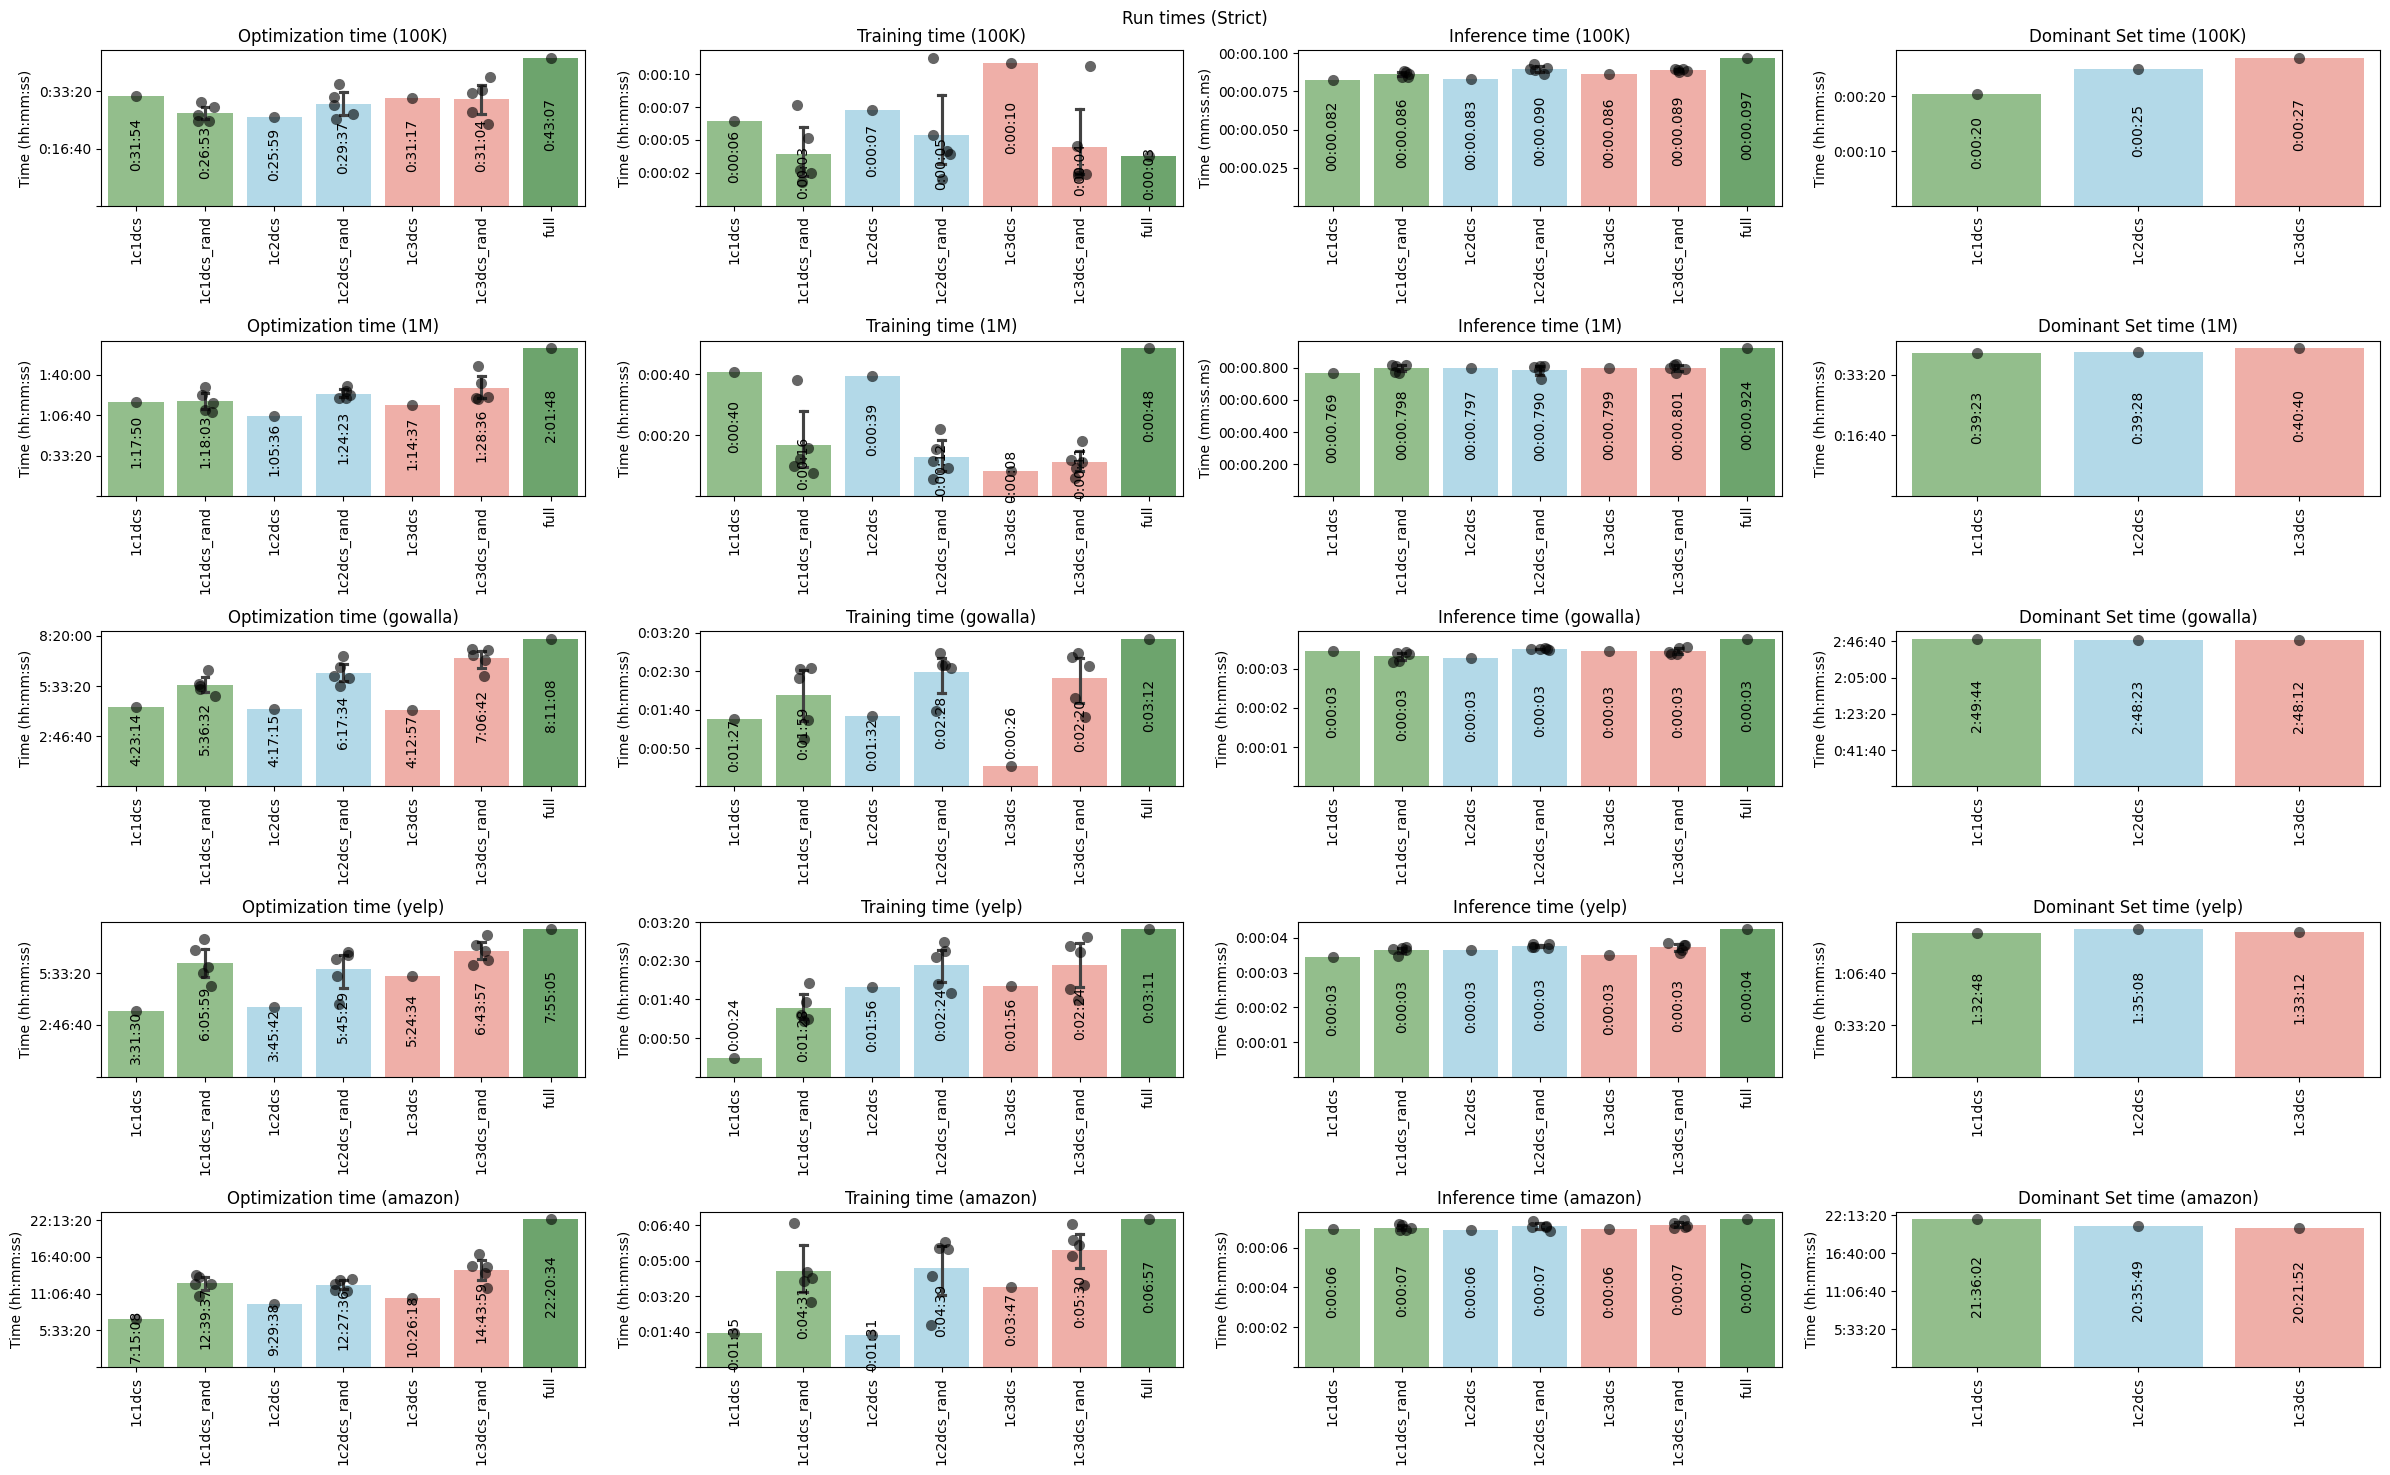

In [25]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

n_plots_height = random_experiments_stats['experiment_grp'].nunique()
n_plots_wide = len(plots)
plt.figure(figsize=(n_plots_wide*6,n_plots_height*3))

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for j,group in enumerate(random_experiments_stats['experiment_grp'].unique()):
    for i, metric in enumerate(plots):
        #plt.subplot(n_plots_height, n_plots_wide, i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment_grp'] == group) & ((random_experiments_stats['experiment_strict']=='strict')  | (random_experiments_stats['experiment']=='full')) ] 

        # Create the barplot
        ax = sns.barplot(data=subset_df[subset_df[metric]>0], x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict, hue='experiment', legend=False) 
        # Iterate through all containers generated by Seaborn's hue
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            # Generate a label list directly from the bar heights in this specific container
            labels = [format_time(val) for val in container.datavalues]
            ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)

        # Add the stripplot
        sns.stripplot(data=subset_df[subset_df[metric]>0], x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15, ax=ax)
        
        plt.title(titles[i]+f' ({group})')
        plt.xlabel('')
        plt.xticks(rotation=90)

        # Use the mean of the actual current metric to decide the axis label
        current_mean = subset_df[metric].mean()
        if current_mean < 1:
            plt.ylabel('Time (mm:ss.ms)')
        else:
            plt.ylabel('Time (hh:mm:ss)')
            
        plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.suptitle('Run times (Strict)')
plt.tight_layout()
plt.savefig(version+'experiments_times_strict.png')
plt.show()

In [26]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )
key = ['experiment', 'experiment_grp', 'experiment_ds', 'experiment_strict' ]

result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result.head()

,experiment,experiment_grp,experiment_ds,experiment_strict,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,best_recall_mean,best_recall_std,cycle_mean,cycle_std,early_stopping_mean,early_stopping_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,100K,1c1dcs,,0.346382,0.0,0.050714,0.0,0.040738,0.0,0.056046,0.0,0.349949,0.0,0.056923,0.0,0.046885,0.0,0.063436,0.0,0.057651,0.0,900.0,0.0,1.0,0.0,2111.864472,0.0,4.238313,0.0,0.090695,0.0,20.437767,0.0,65267.0,303.0,232.0,[1],[64],[0.0005134970540789423],[0.0027428171281445477],[2427],[RMSprop]
1,1c1dcs,100K,1c1dcs,strict,0.560036,0.0,0.017587,0.0,0.015000,0.0,0.018624,0.0,0.569235,0.0,0.024957,0.0,0.018689,0.0,0.027265,0.0,0.017891,0.0,1750.0,0.0,1.0,0.0,1914.439840,0.0,6.480678,0.0,0.082342,0.0,20.437767,0.0,7229.0,303.0,232.0,[4],[96],[0.01852608372473555],[5.071290024292256e-05],[716],[RMSprop]
2,1c1dcs,1M,1c1dcs,,0.581042,0.0,0.069236,0.0,0.030323,0.0,0.061946,0.0,0.579470,0.0,0.073398,0.0,0.032955,0.0,0.067251,0.0,0.069051,0.0,1550.0,0.0,1.0,0.0,6378.876046,0.0,23.478655,0.0,0.859617,0.0,2363.878020,0.0,190231.0,3156.0,1584.0,[1],[32],[0.0004427403826510948],[0.0001819760529014093],[959],[RMSprop]
3,1c1dcs,1M,1c1dcs,strict,0.683425,0.0,0.029427,0.0,0.009545,0.0,0.025881,0.0,0.683343,0.0,0.027604,0.0,0.009354,0.0,0.025241,0.0,0.029399,0.0,3950.0,0.0,0.0,0.0,4670.606876,0.0,40.895363,0.0,0.769231,0.0,2363.878020,0.0,11896.0,3156.0,1584.0,[2],[128],[0.00011132803279953378],[3.136622296234252e-05],[667],[RMSprop]
4,1c1dcs,amazon,1c1dcs,,0.287298,0.0,0.021021,0.0,0.004900,0.0,0.013154,0.0,0.286990,0.0,0.021771,0.0,0.005027,0.0,0.013862,0.0,0.021051,0.0,3950.0,0.0,0.0,0.0,62454.348099,0.0,378.595296,0.0,7.326218,0.0,77762.739275,0.0,858585.0,4799.0,14262.0,[1],[256],[0.0007787505453018097],[0.00045598605516994004],[2278],[RMSprop]


In [27]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in result_viewable.columns }
    result_viewable.rename(rename_dict, axis=1, inplace=True)


In [28]:
result_viewable

,experiment,experiment_grp,experiment_ds,experiment_strict,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,100K,1c1dcs,,0.3464,0.0507,0.0407,0.0560,0.3499,0.0569,0.0469,0.0634,0.0577,900.0000,1.0000,65267.0,303.0,232.0,00:35:11,00:00:04,00:00:00,00:00:20,[1],[64],[0.0005134970540789423],[0.0027428171281445477],[2427],[RMSprop]
1,1c1dcs,100K,1c1dcs,strict,0.5600,0.0176,0.0150,0.0186,0.5692,0.0250,0.0187,0.0273,0.0179,"1,750.0000",1.0000,7229.0,303.0,232.0,00:31:54,00:00:06,00:00:00,00:00:20,[4],[96],[0.01852608372473555],[5.071290024292256e-05],[716],[RMSprop]
2,1c1dcs,1M,1c1dcs,,0.5810,0.0692,0.0303,0.0619,0.5795,0.0734,0.0330,0.0673,0.0691,"1,550.0000",1.0000,190231.0,3156.0,1584.0,01:46:18,00:00:23,00:00:00,00:39:23,[1],[32],[0.0004427403826510948],[0.0001819760529014093],[959],[RMSprop]
3,1c1dcs,1M,1c1dcs,strict,0.6834,0.0294,0.0095,0.0259,0.6833,0.0276,0.0094,0.0252,0.0294,"3,950.0000",0.0000,11896.0,3156.0,1584.0,01:17:50,00:00:40,00:00:00,00:39:23,[2],[128],[0.00011132803279953378],[3.136622296234252e-05],[667],[RMSprop]
4,1c1dcs,amazon,1c1dcs,,0.2873,0.0210,0.0049,0.0132,0.2870,0.0218,0.0050,0.0139,0.0211,"3,950.0000",0.0000,858585.0,4799.0,14262.0,17:20:54,00:06:18,00:00:07,21:36:02,[1],[256],[0.0007787505453018097],[0.00045598605516994004],[2278],[RMSprop]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,full,100K,full,,0.2406,0.1038,0.0495,0.0832,0.2365,0.0973,0.0518,0.0822,0.1229,450.0000,1.0000,81200.0,610.0,9003.0,00:43:07,00:00:03,00:00:00,00:00:00,[1],[256],[0.0005586191809811369],[2.3648996790815136e-05],[3835],[RMSprop]
61,full,1M,full,,0.4476,0.0918,0.0659,0.0927,0.4447,0.1002,0.0770,0.1092,0.0919,"3,800.0000",0.0000,805443.0,6040.0,3682.0,02:01:48,00:00:48,00:00:00,00:00:00,[1],[32],[0.0007928857958215832],[1.207883913872658e-06],[576],[Adam]
62,full,amazon,full,,0.1267,0.0343,0.0075,0.0211,0.1257,0.0350,0.0076,0.0219,0.0342,"3,950.0000",0.0000,2429444.0,52643.0,91599.0,22:20:34,00:06:57,00:00:07,00:00:00,[1],[256],[0.001948110338269317],[6.447923168817336e-05],[2778],[Adam]
63,full,gowalla,full,,0.0887,0.1139,0.0141,0.0634,0.0914,0.1176,0.0145,0.0662,0.1138,"3,950.0000",0.0000,845292.0,29858.0,40981.0,08:11:08,00:03:12,00:00:03,00:00:00,[1],[256],[0.0009463388507176841],[2.8807178813664366e-05],[2234],[RMSprop]


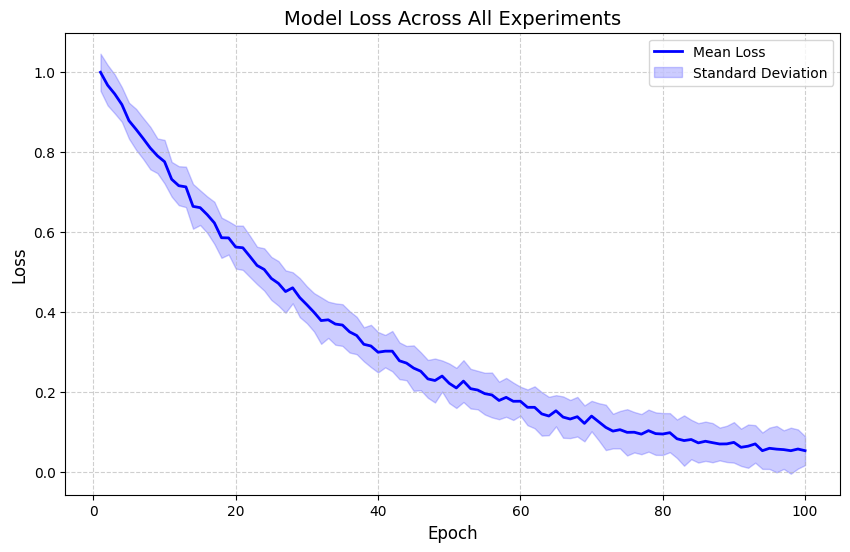

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create a dummy dataframe matching your description
# 50 experiments, each running for 100 epochs
np.random.seed(42)
epochs = 100
mock_data = []

for _ in range(50):
    # Generates a decaying loss curve with unique noise per experiment
    base_loss = np.exp(-np.linspace(0, 3, epochs))
    noise = np.random.normal(0, 0.05, epochs)
    mock_data.append(base_loss + noise)

df = pd.DataFrame({"experiment_id": range(50), "loss_history": mock_data})

# 2. Convert the column of arrays into a standard 2D NumPy array
# Shape will be (number_of_experiments, number_of_epochs)
losses_matrix = np.vstack(df["loss_history"].values)

# 3. Calculate mean and standard deviation across rows (axis=0)
mean_loss = np.mean(losses_matrix, axis=0)
std_loss = np.std(losses_matrix, axis=0)
epochs_range = np.arange(1, len(mean_loss) + 1)

# 4. Plot the aggregate results
plt.figure(figsize=(10, 6))

# Plot the average loss line
plt.plot(epochs_range, mean_loss, color="blue", label="Mean Loss", lw=2)

# Shade the variance region (Mean ± 1 Standard Deviation)
plt.fill_between(
    epochs_range,
    mean_loss - std_loss,
    mean_loss + std_loss,
    color="blue",
    alpha=0.2,
    label="Standard Deviation",
)

# Customizing the plot
plt.title("Model Loss Across All Experiments", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")

plt.show()